# 06 - PatchTST (Mirrored 6 Strategies)

This notebook mirrors the 6-strategy federated transfer-learning setup from MLP/LSTM notebooks using a PatchTST-style architecture.


In [1]:
from pathlib import Path
RUN_MODE = "train"  # "train" or "load"
FORCE_RETRAIN = True  # Publication reruns: set True only when intentionally regenerating artifacts
assert RUN_MODE in {"train", "load"}
MODELS_DIR = Path("saved_models")
RESULTS_DIR = Path("saved_results")
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

def should_retrain(*paths):
    """Train when forced or when any required artifact is missing."""
    return FORCE_RETRAIN or not all(Path(p).exists() for p in paths)

def should_load_existing(*paths):
    """Reuse publication artifacts by default, even when RUN_MODE is train."""
    return (not FORCE_RETRAIN) and all(Path(p).exists() for p in paths)

print("RUN_MODE:", RUN_MODE)
print("FORCE_RETRAIN:", FORCE_RETRAIN)


RUN_MODE: train
FORCE_RETRAIN: True


In [ ]:
import os, random, math, gc, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED =42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print(f"SEED: {SEED}")


DEVICE: cpu
SEED: 123


In [3]:
TRAIN_PATH = "ashrae/train.cleaned_isamu_matt.building_mean_y_ge_1.csv"
BMETA_PATH = "ashrae/building_metadata.csv"
WTRAIN_PATH = "ashrae/weather_train.cleaned.csv"

train = pd.read_csv(TRAIN_PATH)
bmeta = pd.read_csv(BMETA_PATH)
wtrain = pd.read_csv(WTRAIN_PATH)

train = train[train["meter"] == 0].copy()
train["timestamp"] = pd.to_datetime(train["timestamp"])
wtrain["timestamp"] = pd.to_datetime(wtrain["timestamp"])

meta_extra_cols = [c for c in ["site_id", "primary_use", "square_feet", "year_built", "floor_count"] if c in bmeta.columns and c not in train.columns]
bmeta2 = bmeta[["building_id"] + meta_extra_cols].copy()

df = train.merge(bmeta2, on="building_id", how="left")
if "site_id" not in df.columns:
    raise KeyError("site_id is missing after metadata merge. Check train/bmeta columns.")
df = df.merge(wtrain, on=["site_id", "timestamp"], how="left")

def add_time_features(d):
    d["hour"] = d["timestamp"].dt.hour
    d["dow"] = d["timestamp"].dt.dayofweek
    d["month"] = d["timestamp"].dt.month
    d["is_weekend"] = (d["dow"] >= 5).astype(int)
    return d

df = add_time_features(df)

weather_cols = [
    "air_temperature", "dew_temperature", "wind_speed", "cloud_coverage",
    "precip_depth_1_hr", "sea_level_pressure"
]
for c in weather_cols:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].median())

for lag in [1, 24]:
    df[f"lag_{lag}"] = df.groupby("building_id")["meter_reading"].shift(lag)

df["roll24_mean"] = df.groupby("building_id")["meter_reading"].shift(1).rolling(24).mean()
df["roll24_std"] = df.groupby("building_id")["meter_reading"].shift(1).rolling(24).std()

df = df[df[["lag_1", "lag_24", "roll24_mean", "roll24_std"]].notna().all(axis=1)].copy()
df["y"] = np.log1p(df["meter_reading"].values)
df.reset_index(drop=True, inplace=True)

FEATURES = ["hour", "dow", "month", "is_weekend", "meter_reading", "lag_1", "lag_24", "roll24_mean", "roll24_std"]
for c in weather_cols:
    if c in df.columns:
        FEATURES.append(c)
FEATURES = [c for c in FEATURES if c in df.columns]
TARGET = "y"
print("Rows:", len(df), "Buildings:", df["building_id"].nunique(), "Features:", len(FEATURES))


KeyboardInterrupt: 

In [ ]:
# Experiment config (mirrors MLP/LSTM setting style)
N_CLIENTS = 60
CLIENT_SPLIT_SEED = 42       # fixed client/cold-start split across model seeds
MAX_ROWS_PER_CLIENT = 8000
NON_IID_BY_SITE = True
SITES_TO_USE = 6

TRAIN_FRAC = 0.75
VAL_FRAC = 0.10
ENABLE_COLD_START = True
COLD_START_RATIO = 0.20
COLD_TRAIN_DAYS = 14

ROUNDS = 10
SAMPLE_FRAC = 0.25
LOCAL_EPOCHS = 10
LR = 1e-3
K_SIMILAR_BUILDINGS = 5       # Top-K similar buildings for instance/similarity TL

LOOKBACK = 96
HORIZON = 1
MIN_TRAIN_ROWS_COLD = 300
BATCH_SIZE = 256

PATCH_LEN = 16
PATCH_STRIDE = 8
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 3
FF_DIM = 256
DROPOUT = 0.1

WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0

PATCHTST_LOSS_CURVES = []
CURRENT_PATCHTST_STRATEGY = "PatchTST"

def set_patchtst_curve_strategy(name, reset=False):
    global CURRENT_PATCHTST_STRATEGY, PATCHTST_LOSS_CURVES
    CURRENT_PATCHTST_STRATEGY = str(name)
    if reset:
        PATCHTST_LOSS_CURVES = []


In [ ]:
# client selection + split
all_bids = sorted(df["building_id"].unique())
if NON_IID_BY_SITE and "site_id" in df.columns:
    site_counts = df.groupby("site_id")["building_id"].nunique().sort_values(ascending=False)
    selected_sites = site_counts.index[:SITES_TO_USE].tolist()
    candidate_bids = sorted(df[df["site_id"].isin(selected_sites)]["building_id"].unique())
else:
    candidate_bids = all_bids

client_split_rng = np.random.default_rng(CLIENT_SPLIT_SEED)
cold_split_rng = np.random.default_rng(CLIENT_SPLIT_SEED + 1)
if len(candidate_bids) > N_CLIENTS:
    usable_bids = sorted(client_split_rng.choice(candidate_bids, size=N_CLIENTS, replace=False).tolist())
else:
    usable_bids = candidate_bids

cold_bids = set()
if ENABLE_COLD_START:
    k = max(1, int(len(usable_bids) * COLD_START_RATIO))
    cold_bids = set(cold_split_rng.choice(usable_bids, size=k, replace=False).tolist())
cold_set = set(cold_bids)

client_data = {}
for bid in usable_bids:
    d = df[df["building_id"] == bid].sort_values("timestamp").copy()
    if len(d) > MAX_ROWS_PER_CLIENT:
        d = d.iloc[-MAX_ROWS_PER_CLIENT:]
    d = d.reset_index(drop=True)
    n = len(d)
    train_end = int(n * TRAIN_FRAC)
    val_end = int(n * (TRAIN_FRAC + VAL_FRAC))

    if train_end <= LOOKBACK + 1 or val_end <= train_end + 1 or n <= val_end + 1:
        continue

    train_orig_end = train_end
    if bid in cold_bids:
        start = d["timestamp"].min()
        cold_train_end = int((d["timestamp"] < (start + pd.Timedelta(days=COLD_TRAIN_DAYS))).sum())
        cold_train_end = max(MIN_TRAIN_ROWS_COLD, cold_train_end)
        cold_train_end = min(cold_train_end, train_orig_end, val_end - HORIZON - 1)
        train_end = cold_train_end

    if train_end <= LOOKBACK + HORIZON:
        continue

    client_data[bid] = {
        "full": d,
        "train_end": train_end,
        "train_orig_end": train_orig_end,
        "val_end": val_end,
        "cold_start": bid in cold_bids,
    }

usable_bids = sorted(client_data.keys())
cold_bids = {b for b in cold_bids if b in client_data}
cold_set = set(cold_bids)
source_bids = [b for b in usable_bids if b not in cold_bids]
selected_client_df = df[df["building_id"].isin(usable_bids)].copy()

print("Selected federated clients:", selected_client_df["building_id"].nunique())
print("Selected sites:", selected_client_df["site_id"].nunique())
print("Cold-start clients:", len(cold_set))
print("Warm-start clients:", len(source_bids))
print("usable", len(usable_bids), "source", len(source_bids), "cold", len(cold_bids))
if cold_bids:
    cold_train_rows = [client_data[b]["train_end"] for b in cold_bids]
    warm_train_rows = [client_data[b]["train_end"] for b in source_bids]
    print(
        f"Cold-start train rows: mean={np.mean(cold_train_rows):.1f}, "
        f"min={np.min(cold_train_rows)}, max={np.max(cold_train_rows)} "
        f"(COLD_TRAIN_DAYS={COLD_TRAIN_DAYS}, MIN_TRAIN_ROWS_COLD={MIN_TRAIN_ROWS_COLD})"
    )
    print(
        f"Warm/source train rows: mean={np.mean(warm_train_rows):.1f}, "
        f"min={np.min(warm_train_rows)}, max={np.max(warm_train_rows)}"
    )

Selected federated clients: 60
Selected sites: 6
Cold-start clients: 12
Warm-start clients: 48
usable 60 source 48 cold 12
Cold-start train rows: mean=336.0, min=336, max=336 (COLD_TRAIN_DAYS=14, MIN_TRAIN_ROWS_COLD=300)
Warm/source train rows: mean=5956.8, min=5585, max=6000


In [ ]:
# scale on source train only
scaler = StandardScaler()
parts = []
for bid in source_bids:
    d = client_data[bid]["full"]
    parts.append(d.iloc[:client_data[bid]["train_end"]][FEATURES])
scaler.fit(pd.concat(parts, axis=0).values)

def make_windows(arr_x, arr_y, start_idx, end_idx, lookback=96, horizon=1):
    xs, ys = [], []
    for t in range(max(start_idx, lookback), end_idx - horizon + 1):
        xs.append(arr_x[t - lookback:t])
        ys.append(arr_y[t + horizon - 1])
    if len(xs) == 0:
        return np.empty((0, lookback, arr_x.shape[1]), np.float32), np.empty((0, 1), np.float32)
    return np.asarray(xs, np.float32), np.asarray(ys, np.float32).reshape(-1, 1)

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def split_windows_for_bid(bid):
    d = client_data[bid]["full"]
    Xall = scaler.transform(d[FEATURES].values).astype(np.float32)
    yall = d[TARGET].values.astype(np.float32)
    tr_end = client_data[bid]["train_end"]
    va_end = client_data[bid]["val_end"]
    Xtr, ytr = make_windows(Xall, yall, 0, tr_end, LOOKBACK, HORIZON)
    Xva, yva = make_windows(Xall, yall, tr_end, va_end, LOOKBACK, HORIZON)
    Xte, yte = make_windows(Xall, yall, va_end, len(d), LOOKBACK, HORIZON)
    return Xtr, ytr, Xva, yva, Xte, yte

def loaders_for_bid(bid, batch=BATCH_SIZE):
    Xtr, ytr, Xva, yva, Xte, yte = split_windows_for_bid(bid)
    tr = DataLoader(SeqDataset(Xtr, ytr), batch_size=batch, shuffle=True)
    va = DataLoader(SeqDataset(Xva, yva), batch_size=batch, shuffle=False)
    te = DataLoader(SeqDataset(Xte, yte), batch_size=batch, shuffle=False)
    return tr, va, te


In [ ]:
# PatchTST-style model with separate encoder/head for personalized and progressive strategies
class PatchTSTEncoder(nn.Module):
    def __init__(self, n_features, lookback, patch_len, patch_stride, d_model, n_heads, n_layers, ff_dim, dropout):
        super().__init__()
        self.patch_len = patch_len
        self.patch_stride = patch_stride
        self.n_patches = 1 + (lookback - patch_len) // patch_stride
        self.patch_proj = nn.Linear(patch_len * n_features, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu", norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

    def forward(self, x):
        p = x.unfold(1, self.patch_len, self.patch_stride).permute(0,1,3,2).contiguous()
        p = p.view(x.size(0), self.n_patches, -1)
        z = self.patch_proj(p) + self.pos_emb
        z = self.encoder(z)
        return z.mean(dim=1)

class PatchTSTModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.encoder = PatchTSTEncoder(
            n_features=n_features, lookback=LOOKBACK, patch_len=PATCH_LEN, patch_stride=PATCH_STRIDE,
            d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, ff_dim=FF_DIM, dropout=DROPOUT
        )
        self.head = nn.Sequential(nn.LayerNorm(D_MODEL), nn.Linear(D_MODEL, 1))
    def forward(self, x):
        return self.head(self.encoder(x))

def make_model():
    return PatchTSTModel(len(FEATURES)).to(DEVICE)

def get_weights(model):
    return [v.detach().cpu().numpy() for _, v in model.state_dict().items()]

def set_weights(model, weights):
    sd = model.state_dict()
    for (k, _), w in zip(sd.items(), weights):
        sd[k] = torch.tensor(w)
    model.load_state_dict(sd)

def average_weights(weights_list):
    out = []
    for ws in zip(*weights_list):
        out.append(np.mean(np.stack(ws, axis=0), axis=0))
    return out


In [ ]:
def mean_loader_loss(model, loader, loss_fn):
    model.eval(); tot=0.0; n=0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            loss = loss_fn(model(X), y)
            b = len(y); tot += loss.item() * b; n += b
    return tot / max(n, 1)


def train_one(model, loader, epochs=1, lr=1e-3, val_loader=None, freeze_encoder=False, record_name='PatchTST'):
    if freeze_encoder:
        for p in model.encoder.parameters():
            p.requires_grad = False
    else:
        for p in model.encoder.parameters():
            p.requires_grad = True

    trainable = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(trainable, lr=lr, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()
    hist = {'train_loss': [], 'val_loss': []}

    for _ in range(epochs):
        model.train(); tot=0.0; n=0
        for X,y in loader:
            X,y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(X), y)
            loss.backward()
            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(trainable, GRAD_CLIP_NORM)
            opt.step()
            b = len(y); tot += loss.item() * b; n += b
        hist['train_loss'].append(tot / max(n,1))
        if val_loader is not None:
            hist['val_loss'].append(mean_loader_loss(model, val_loader, loss_fn))
        else:
            hist['val_loss'].append(np.nan)

    name = str(record_name) if record_name not in [None, '', 'PatchTST'] else str(CURRENT_PATCHTST_STRATEGY)
    PATCHTST_LOSS_CURVES.append({'strategy': name, 'name': name, 'model': 'PatchTST', 'train_loss': hist['train_loss'], 'val_loss': hist['val_loss']})
    return hist

def eval_model(model, loader):
    ys, ps = [], []
    model.eval()
    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            pred = model(X).cpu().numpy().reshape(-1)
            ys.append(y.numpy().reshape(-1)); ps.append(pred)
    if len(ys)==0:
        return np.nan, np.nan, np.nan, np.nan
    y_true = np.concatenate(ys); y_pred = np.concatenate(ps)

    # MAE/RMSE are reported in log1p(meter_reading) space to match the training target.
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))

    # Keep percentage metrics on the original meter_reading scale.
    y_true_raw = np.expm1(y_true); y_pred_raw = np.expm1(y_pred)
    rmse_raw = math.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    cvrmse = (rmse_raw / max(np.mean(y_true_raw), 1e-8)) * 100
    wape = (np.sum(np.abs(y_true_raw-y_pred_raw)) / max(np.sum(np.abs(y_true_raw)), 1e-8)) * 100
    return mae, rmse, cvrmse, wape


In [ ]:
# Benchmark timing hooks (PatchTST)
import time
import pandas as pd
import numpy as np

strategy_runtime_patchtst = globals().get("strategy_runtime_patchtst", {})
if not isinstance(strategy_runtime_patchtst, dict):
    strategy_runtime_patchtst = {}

def _benchmark_strategy_name_patchtst(record_name=None):
    if record_name not in [None, "", "PatchTST", "MLP", "LSTM", "PatchTST"]:
        return str(record_name)
    return str(globals().get("CURRENT_PATCHTST_STRATEGY", record_name or "PatchTST"))

def _add_benchmark_time_patchtst(strategy, field, seconds):
    rec = strategy_runtime_patchtst.setdefault(str(strategy), {
        "train_sec": 0.0,
        "eval_sec": 0.0,
        "train_calls": 0,
        "eval_calls": 0,
    })
    rec[field] = float(rec.get(field, 0.0)) + float(seconds)
    if field == "train_sec":
        rec["train_calls"] = int(rec.get("train_calls", 0)) + 1
    elif field == "eval_sec":
        rec["eval_calls"] = int(rec.get("eval_calls", 0)) + 1

if "train_one" in globals() and not getattr(train_one, "_benchmark_timed", False):
    _orig_train_one_benchmark = train_one
    def train_one(*args, **kwargs):
        strategy = _benchmark_strategy_name_patchtst(kwargs.get("record_name"))
        t0 = time.perf_counter()
        result = _orig_train_one_benchmark(*args, **kwargs)
        _add_benchmark_time_patchtst(strategy, "train_sec", time.perf_counter() - t0)
        return result
    train_one._benchmark_timed = True

if "eval_model" in globals() and not getattr(eval_model, "_benchmark_timed", False):
    _orig_eval_model_benchmark = eval_model
    def eval_model(*args, **kwargs):
        strategy = _benchmark_strategy_name_patchtst()
        t0 = time.perf_counter()
        result = _orig_eval_model_benchmark(*args, **kwargs)
        _add_benchmark_time_patchtst(strategy, "eval_sec", time.perf_counter() - t0)
        return result
    eval_model._benchmark_timed = True

In [ ]:
# Similarity profiles for instance/similarity-aware strategies
profiles = {}
for bid in source_bids:
    d = client_data[bid]['full'].iloc[:client_data[bid]['train_end']]
    h = d.groupby('hour')['meter_reading'].mean().reindex(range(24), fill_value=0).values
    w = d.groupby('dow')['meter_reading'].mean().reindex(range(7), fill_value=0).values
    profiles[bid] = np.concatenate([h, w])

profile_mat = np.stack([profiles[b] for b in source_bids], axis=0)
profile_nn = NearestNeighbors(n_neighbors=min(K_SIMILAR_BUILDINGS, len(source_bids)), metric='euclidean').fit(profile_mat)

sim_matrix = {}
for i, bi in enumerate(source_bids):
    vi = profiles[bi]
    sims = {}
    for bj in source_bids:
        vj = profiles[bj]
        dist = np.linalg.norm(vi - vj)
        sims[bj] = 1.0 / (1.0 + dist)
    total = sum(sims.values())
    sim_matrix[bi] = {k: v/total for k,v in sims.items()}


In [ ]:
# Pretrain base model on pooled source data
def pooled_loader_for_source(batch=BATCH_SIZE):
    Xs, ys = [], []
    for bid in source_bids:
        Xtr, ytr, _, _, _, _ = split_windows_for_bid(bid)
        if len(Xtr)>0:
            Xs.append(Xtr); ys.append(ytr)
    X = np.concatenate(Xs, axis=0); y = np.concatenate(ys, axis=0)
    return DataLoader(SeqDataset(X,y), batch_size=batch, shuffle=True)

pretrain_path = MODELS_DIR / f'patchtst_pretrain_seed{int(SEED)}.pt'
if RUN_MODE == 'train' and should_retrain(pretrain_path):
    pretrain_model = make_model()
    set_patchtst_curve_strategy('Pretrain-PatchTST', reset=True)
    train_one(pretrain_model, pooled_loader_for_source(), epochs=5, lr=LR, record_name='Pretrain-PatchTST')
    pretrain_weights = get_weights(pretrain_model)
    torch.save(pretrain_model.state_dict(), pretrain_path)
else:
    pretrain_model = make_model()
    pretrain_model.load_state_dict(torch.load(pretrain_path, map_location=DEVICE))
    pretrain_weights = get_weights(pretrain_model)


C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


In [ ]:
# Strategy 1: FTL
def eval_strategy(weights, name):
    rows = []
    for bid in usable_bids:
        _, _, te = loaders_for_bid(bid)
        m = make_model(); set_weights(m, weights)
        mae, rmse, cvrmse, wape = eval_model(m, te)
        rows.append({'Strategy': name, 'building_id': bid, 'cold_start': bid in cold_bids, 'mae': mae, 'rmse': rmse, 'cvrmse': cvrmse, 'wape': wape, 'metric_scale': 'log_target'})
    return pd.DataFrame(rows)

PATCHTST_METRIC_SCALE = 'log_target'

def mark_log_metric_results(df_res):
    df_res = df_res.copy()
    if {'mae', 'rmse'}.issubset(df_res.columns):
        df_res['metric_scale'] = PATCHTST_METRIC_SCALE
    return df_res

def is_log_metric_results(df_res):
    return (
        isinstance(df_res, pd.DataFrame)
        and 'metric_scale' in df_res.columns
        and (df_res['metric_scale'] == PATCHTST_METRIC_SCALE).all()
    )

def load_log_metric_results(path, label='results'):
    if not should_load_existing(path):
        return None
    df_res = pd.read_csv(path)
    if is_log_metric_results(df_res):
        print('Loaded results:', path)
        return df_res
    print(f'Existing {label} use raw-scale MAE/RMSE; recomputing log-scale metrics:', path)
    return None

def save_strategy_results(df_res, filename):
    df_res = mark_log_metric_results(df_res)
    out = RESULTS_DIR / filename
    df_res.to_csv(out, index=False)
    print('Saved results:', out)
    return df_res

def print_metric_block(title, df_res):
    print(f"\n{title} Results:")
    print(f"  Mean MAE (log): {df_res['mae'].mean():.4f}")
    print(f"  Mean RMSE (log): {df_res['rmse'].mean():.4f}")
    print(f"  Mean CVRMSE (raw %): {df_res['cvrmse'].mean():.2f}%")
    print(f"  Mean WAPE (raw %): {df_res['wape'].mean():.2f}%")
    if 'cold_start' in df_res.columns and df_res['cold_start'].any():
        cold = df_res[df_res['cold_start']]
        print(f"  Cold-start MAE (log): {cold['mae'].mean():.4f}")
        print(f"  Cold-start CVRMSE: {cold['cvrmse'].mean():.2f}%")

set_patchtst_curve_strategy('FTL', reset=False)
weights = pretrain_weights
ftl_path = MODELS_DIR / f'patchtst_ftl_seed{int(SEED)}.pkl'

if RUN_MODE == 'train' and should_retrain(ftl_path):
    for r in range(ROUNDS):
        k = max(2, int(len(source_bids)*SAMPLE_FRAC))
        sampled = random.sample(source_bids, k)
        local_ws = []
        for bid in sampled:
            tr, va, _ = loaders_for_bid(bid)
            m = make_model(); set_weights(m, weights)
            train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va)
            local_ws.append(get_weights(m))
        weights = average_weights(local_ws)
    ftl_weights = weights
    with open(ftl_path,'wb') as f: pickle.dump(ftl_weights,f)
else:
    with open(ftl_path,'rb') as f: ftl_weights = pickle.load(f)

ftl_results_path = RESULTS_DIR / f'patchtst_ftl_results_seed{int(SEED)}.csv'
df_ftl_patchtst = load_log_metric_results(ftl_results_path, 'FTL results')
if df_ftl_patchtst is None:
    df_ftl_patchtst = eval_strategy(ftl_weights, 'FTL')
    df_ftl_patchtst = save_strategy_results(df_ftl_patchtst, f'patchtst_ftl_results_seed{int(SEED)}.csv')
df_ftl_patchtst['Strategy'] = 'FTL'
print_metric_block('FTL PatchTST', df_ftl_patchtst)


In [ ]:
# PRETRAINING FRACTION SWEEP (FTL BASELINE - PatchTST)
# Used by the resource-allocation diagnostic near the end of the notebook.
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRETRAIN_FRACS_PATCHTST = [0.10, 0.25, 0.50, 0.75, 1.00]
patchtst_pretrain_sweep_path = RESULTS_DIR / f"patchtst_pretrain_sweep_seed{int(SEED)}.csv"

def _pooled_loader_for_source_frac_patchtst(frac, batch=BATCH_SIZE):
    Xs, ys = [], []
    for bid in source_bids:
        Xtr, ytr, _, _, _, _ = split_windows_for_bid(bid)
        if len(Xtr) > 0:
            Xs.append(Xtr)
            ys.append(ytr)
    if not Xs:
        raise RuntimeError("No PatchTST source pretraining windows available.")
    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    n = max(1, int(len(X) * float(frac)))
    rng = np.random.default_rng(SEED + int(round(float(frac) * 1000)))
    idx = rng.choice(len(X), size=n, replace=False)
    return DataLoader(SeqDataset(X[idx], y[idx]), batch_size=batch, shuffle=True), n

def _patchtst_sweep_metrics(df_eval):
    warm = df_eval[~df_eval["cold_start"]]
    cold = df_eval[df_eval["cold_start"]]
    return {
        "overall_mae": float(df_eval["mae"].mean()),
        "warm_mae": float(warm["mae"].mean()) if len(warm) else np.nan,
        "cold_mae": float(cold["mae"].mean()) if len(cold) else np.nan,
        "cvrmse": float(df_eval["cvrmse"].mean()),
        "wape": float(df_eval["wape"].mean()),
    }

if patchtst_pretrain_sweep_path.exists() and not FORCE_RETRAIN:
    pretrain_sweep_patchtst = pd.read_csv(patchtst_pretrain_sweep_path)
    if "metric_scale" in pretrain_sweep_patchtst.columns and (pretrain_sweep_patchtst["metric_scale"] == PATCHTST_METRIC_SCALE).all():
        print("Loaded PatchTST pretraining sweep:", patchtst_pretrain_sweep_path)
    else:
        print("Existing PatchTST pretraining sweep uses raw-scale MAE; recomputing log-scale metrics:", patchtst_pretrain_sweep_path)
        pretrain_sweep_patchtst = pd.DataFrame()
else:
    pretrain_sweep_patchtst = pd.DataFrame()

done_fracs = set()
if isinstance(pretrain_sweep_patchtst, pd.DataFrame) and len(pretrain_sweep_patchtst) and "pretrain_frac" in pretrain_sweep_patchtst.columns:
    done_fracs = set(np.round(pretrain_sweep_patchtst["pretrain_frac"].astype(float), 4))

rows = [] if FORCE_RETRAIN else pretrain_sweep_patchtst.to_dict("records")

for frac in PRETRAIN_FRACS_PATCHTST:
    frac_key = round(float(frac), 4)
    if frac_key in done_fracs and not FORCE_RETRAIN:
        continue

    np.random.seed(SEED)
    random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    loader_frac, n_rows = _pooled_loader_for_source_frac_patchtst(frac)
    print(f"\n[PatchTST Pretrain Sweep] frac={frac:.2f}, pretrain_rows={n_rows}")

    sweep_model = make_model()
    train_one(sweep_model, loader_frac, epochs=5, lr=LR, record_name="PatchTST pretrain-sweep")
    sweep_weights = get_weights(sweep_model)

    k = max(2, int(len(source_bids) * SAMPLE_FRAC))
    for r in range(ROUNDS):
        sampled = random.sample(list(source_bids), k)
        local_ws = []
        for bid in sampled:
            tr, va, _ = loaders_for_bid(bid)
            if len(tr.dataset) == 0:
                continue
            m = make_model()
            set_weights(m, sweep_weights)
            train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST FTL pretrain-sweep")
            local_ws.append(get_weights(m))
        if local_ws:
            sweep_weights = average_weights(local_ws)

    df_eval = eval_strategy(sweep_weights, "FTL pretrain-sweep")
    rows.append({
        "strategy": "FTL",
        "pretrain_frac": float(frac),
        "pretrain_rows": int(n_rows),
        "metric_scale": PATCHTST_METRIC_SCALE,
        **_patchtst_sweep_metrics(df_eval),
    })

    pretrain_sweep_patchtst = pd.DataFrame(rows).sort_values(["strategy", "pretrain_frac"]).reset_index(drop=True)
    pretrain_sweep_patchtst.to_csv(patchtst_pretrain_sweep_path, index=False)
    print("Saved partial PatchTST pretraining sweep:", patchtst_pretrain_sweep_path)

pretrain_sweep_patchtst = pd.DataFrame(rows).sort_values(["strategy", "pretrain_frac"]).reset_index(drop=True)
display(pretrain_sweep_patchtst)

if len(pretrain_sweep_patchtst):
    plt.figure(figsize=(8, 4))
    plt.plot(pretrain_sweep_patchtst["pretrain_frac"] * 100, pretrain_sweep_patchtst["cold_mae"], marker="o")
    plt.xlabel("Source pretraining data used (%)")
    plt.ylabel("Cold-start MAE (log)")
    plt.title("PatchTST: Cold-start MAE vs Pretraining Data Volume")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# Baselines: Local-only training and standard FedAvg (from scratch)

def evaluate_local_only_patchtst(local_epochs=None, lr=LR):
    """Train one PatchTST per building using only its local train split."""
    if local_epochs is None:
        local_epochs = max(1, ROUNDS * LOCAL_EPOCHS)

    rows = []
    for bid in usable_bids:
        m = make_model()
        tr, va, te = loaders_for_bid(bid)
        train_one(m, tr, epochs=local_epochs, lr=lr, val_loader=va, record_name='0. Local-only-PatchTST')
        mae, rmse, cvrmse, wape = eval_model(m, te)
        rows.append((bid, mae, rmse, cvrmse, wape, bid in cold_bids))

    return mark_log_metric_results(pd.DataFrame(rows, columns=['building_id', 'mae', 'rmse', 'cvrmse', 'wape', 'cold_start']))


def evaluate_fedavg_scratch_patchtst(rounds=ROUNDS, sample_frac=SAMPLE_FRAC, local_epochs=LOCAL_EPOCHS, lr=LR):
    """Standard FedAvg that starts from random initialization (no pretraining)."""
    global_model = make_model()
    weights = get_weights(global_model)

    k = max(2, int(len(usable_bids) * sample_frac))
    for r in range(rounds):
        sampled = random.sample(list(usable_bids), k)
        local_ws = []
        for bid in sampled:
            tr, va, _ = loaders_for_bid(bid)
            m = make_model(); set_weights(m, weights)
            train_one(m, tr, epochs=local_epochs, lr=lr, val_loader=va, record_name='1b. FedAvg-NoPretrain-PatchTST')
            local_ws.append(get_weights(m))
        weights = average_weights(local_ws)
        print(f'Scratch FedAvg-PatchTST Round {r+1}/{rounds} complete')

    return eval_strategy(weights, 'FedAvg (No Pretrain)')


print('=' * 60)
print('PATCHTST BASELINES')
set_patchtst_curve_strategy('0. Local-only-PatchTST', reset=False)
print('=' * 60)

if 'df_local_patchtst' not in globals() and 'df_local_only_patchtst' in globals():
    df_local_patchtst = df_local_only_patchtst.copy()
if 'df_local_only_patchtst' not in globals() and 'df_local_patchtst' in globals():
    df_local_only_patchtst = df_local_patchtst.copy()

if 'df_scratch_patchtst' not in globals() and 'df_fedavg_scratch_patchtst' in globals():
    df_scratch_patchtst = df_fedavg_scratch_patchtst.copy()
if 'df_fedavg_scratch_patchtst' not in globals() and 'df_scratch_patchtst' in globals():
    df_fedavg_scratch_patchtst = df_scratch_patchtst.copy()

local_only_results_path = RESULTS_DIR / f'patchtst_local_only_results_seed{int(SEED)}.csv'
fedavg_no_pretrain_results_path = RESULTS_DIR / f'patchtst_fedavg_no_pretrain_results_seed{int(SEED)}.csv'

for _df_name in ['df_local_patchtst', 'df_local_only_patchtst', 'df_scratch_patchtst', 'df_fedavg_scratch_patchtst']:
    if _df_name in globals() and not is_log_metric_results(globals()[_df_name]):
        print(f'Ignoring in-kernel raw-scale PatchTST results: {_df_name}')
        del globals()[_df_name]

if 'df_local_patchtst' not in globals() and 'df_local_only_patchtst' not in globals():
    df_local_patchtst = load_log_metric_results(local_only_results_path, 'Local-only PatchTST baseline')
    if df_local_patchtst is not None:
        df_local_only_patchtst = df_local_patchtst.copy()
    else:
        print('Computing Local-only PatchTST baseline...')
        df_local_patchtst = evaluate_local_only_patchtst()
        df_local_only_patchtst = df_local_patchtst.copy()
        save_strategy_results(df_local_patchtst.assign(Strategy='Local-only'), f'patchtst_local_only_results_seed{int(SEED)}.csv')
else:
    print('Local-only PatchTST baseline found in kernel; reusing it.')

if 'df_scratch_patchtst' not in globals() and 'df_fedavg_scratch_patchtst' not in globals():
    df_scratch_patchtst = load_log_metric_results(fedavg_no_pretrain_results_path, 'standard FedAvg PatchTST baseline')
    if df_scratch_patchtst is not None:
        df_fedavg_scratch_patchtst = df_scratch_patchtst.copy()
    else:
        print('Computing standard FedAvg (from scratch) PatchTST baseline...')
        df_scratch_patchtst = evaluate_fedavg_scratch_patchtst()
        df_fedavg_scratch_patchtst = df_scratch_patchtst.copy()
        save_strategy_results(df_scratch_patchtst, f'patchtst_fedavg_no_pretrain_results_seed{int(SEED)}.csv')
else:
    print('Scratch FedAvg PatchTST baseline found in kernel; reusing it.')

print('Baseline summary (PatchTST):')
for name, df_res in [
    ('Local-only training', df_local_patchtst),
    ('Standard FedAvg (from scratch)', df_scratch_patchtst),
]:
    print(f"{name}: MAE(log)={df_res['mae'].mean():.4f}, Warm={df_res[~df_res['cold_start']]['mae'].mean():.4f}, Cold={df_res[df_res['cold_start']]['mae'].mean():.4f}, CVRMSE={df_res['cvrmse'].mean():.2f}%")


---

# Centralized Global Model (PatchTST)

Train a single PatchTST on pooled source (warm-start) training data, then evaluate on all buildings.
This mirrors the LSTM centralized baseline.

---


In [ ]:
print('=' * 60)
print('CENTRALIZED GLOBAL MODEL (PatchTST)')
set_patchtst_curve_strategy('C. Centralized-PatchTST', reset=False)
print('=' * 60)

def pooled_loader_for_source(batch=BATCH_SIZE):
    Xs, ys = [], []
    for bid in source_bids:
        Xtr, ytr, _, _, _, _ = split_windows_for_bid(bid)
        if len(Xtr) > 0:
            Xs.append(Xtr); ys.append(ytr)
    if not Xs:
        raise RuntimeError('No source training windows found for centralized PatchTST.')
    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    return DataLoader(SeqDataset(X, y), batch_size=BATCH_SIZE, shuffle=True)

centralized_results_path = RESULTS_DIR / f'patchtst_centralized_results_seed{int(SEED)}.csv'
centralized_weights_path = MODELS_DIR / f'patchtst_centralized_seed{int(SEED)}.pkl'

if 'df_central_patchtst' in globals() and not is_log_metric_results(df_central_patchtst):
    print('Ignoring in-kernel raw-scale PatchTST results: df_central_patchtst')
    del df_central_patchtst

if 'df_central_patchtst' not in globals():
    df_central_patchtst = load_log_metric_results(centralized_results_path, 'Centralized PatchTST baseline')
    if df_central_patchtst is None:
        central_patchtst = make_model()
        train_one(central_patchtst, pooled_loader_for_source(), epochs=5, lr=1e-3, record_name='C. Centralized-PatchTST')
        weights_central_patchtst = get_weights(central_patchtst)
        with open(centralized_weights_path, 'wb') as f:
            pickle.dump(weights_central_patchtst, f)
        df_central_patchtst = eval_strategy(weights_central_patchtst, 'Centralized')
        save_strategy_results(df_central_patchtst, f'patchtst_centralized_results_seed{int(SEED)}.csv')
else:
    print('Centralized PatchTST baseline found in kernel; reusing it.')

print('\nCentralized PatchTST Results:')
print(f"  Mean MAE (log): {df_central_patchtst['mae'].mean():.4f}")
print(f"  Mean RMSE (log): {df_central_patchtst['rmse'].mean():.4f}")
print(f"  Mean CVRMSE (raw %): {df_central_patchtst['cvrmse'].mean():.2f}%")
print(f"  Mean WAPE (raw %): {df_central_patchtst['wape'].mean():.2f}%")
print(f"  Cold-start MAE (log): {df_central_patchtst[df_central_patchtst['cold_start']]['mae'].mean():.4f}")
print(f"  Cold-start CVRMSE: {df_central_patchtst[df_central_patchtst['cold_start']]['cvrmse'].mean():.2f}%")


In [ ]:
# Strategy 2: Personalized-FL (global encoder + local heads)
set_patchtst_curve_strategy('Personalized-FL', reset=False)

def split_encoder_head(weights):
    m = make_model(); set_weights(m, weights)
    enc = [v.detach().cpu().numpy() for _, v in m.encoder.state_dict().items()]
    head = [v.detach().cpu().numpy() for _, v in m.head.state_dict().items()]
    return enc, head

def merge_encoder_head(enc_w, head_w):
    m = make_model()
    enc_sd = m.encoder.state_dict(); head_sd = m.head.state_dict()
    for (k,_),w in zip(enc_sd.items(), enc_w): enc_sd[k] = torch.tensor(w)
    for (k,_),w in zip(head_sd.items(), head_w): head_sd[k] = torch.tensor(w)
    m.encoder.load_state_dict(enc_sd); m.head.load_state_dict(head_sd)
    return get_weights(m)

personalized_path = MODELS_DIR / f'patchtst_personalized_seed{int(SEED)}.pkl'
global_enc, base_head = split_encoder_head(pretrain_weights)
pers_heads = {bid: base_head for bid in source_bids}

if RUN_MODE == 'train' and should_retrain(personalized_path):
    for r in range(ROUNDS):
        k = max(2, int(len(source_bids)*SAMPLE_FRAC))
        sampled = random.sample(source_bids, k)
        enc_updates = []
        for bid in sampled:
            tr, va, _ = loaders_for_bid(bid)
            m = make_model(); set_weights(m, merge_encoder_head(global_enc, pers_heads[bid]))
            train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va)
            e, h = split_encoder_head(get_weights(m))
            enc_updates.append(e); pers_heads[bid] = h
        global_enc = average_weights(enc_updates)
    with open(personalized_path,'wb') as f: pickle.dump({'enc':global_enc,'heads':pers_heads},f)
else:
    with open(personalized_path,'rb') as f:
        tmp = pickle.load(f); global_enc, pers_heads = tmp['enc'], tmp['heads']


C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.Transformer

In [ ]:
# Strategy 3: Progressive Unfreezing
set_patchtst_curve_strategy('Progressive Unfreezing', reset=False)
weights_prog = pretrain_weights
progressive_path = MODELS_DIR / f'patchtst_progressive_seed{int(SEED)}.pkl'

if RUN_MODE == 'train' and should_retrain(progressive_path):
    frozen_rounds = max(1, ROUNDS // 3)
    for r in range(ROUNDS):
        freeze_encoder = (r < frozen_rounds)
        k = max(2, int(len(source_bids)*SAMPLE_FRAC))
        sampled = random.sample(source_bids, k)
        local_ws = []
        for bid in sampled:
            tr, va, _ = loaders_for_bid(bid)
            m = make_model(); set_weights(m, weights_prog)
            train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, freeze_encoder=freeze_encoder)
            local_ws.append(get_weights(m))
        weights_prog = average_weights(local_ws)
    with open(progressive_path,'wb') as f: pickle.dump(weights_prog,f)
else:
    with open(progressive_path,'rb') as f: weights_prog = pickle.load(f)


C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.Transformer

In [ ]:
# Strategy 4: Instance-TL (augment each client with nearest source profiles)
set_patchtst_curve_strategy('Instance-TL', reset=False)
weights_inst = pretrain_weights
instance_path = MODELS_DIR / f'patchtst_instance_seed{int(SEED)}.pkl'

def augmented_loader_for_bid(bid, k_neighbors=K_SIMILAR_BUILDINGS, batch=BATCH_SIZE):
    Xtr, ytr, _, _, _, _ = split_windows_for_bid(bid)
    if bid in profiles:
        v = profiles[bid].reshape(1,-1)
    else:
        d = client_data[bid]['full'].iloc[:client_data[bid]['train_end']]
        h = d.groupby('hour')['meter_reading'].mean().reindex(range(24), fill_value=0).values
        w = d.groupby('dow')['meter_reading'].mean().reindex(range(7), fill_value=0).values
        v = np.concatenate([h,w]).reshape(1,-1)
    nn_idx = profile_nn.kneighbors(v, return_distance=False)[0]
    nbrs = [source_bids[i] for i in nn_idx[:k_neighbors]]
    Xs, ys = [Xtr], [ytr]
    for nb in nbrs:
        Xn, yn, _, _, _, _ = split_windows_for_bid(nb)
        take = min(len(Xn), max(50, len(Xtr)//4))
        if take > 0:
            Xs.append(Xn[:take]); ys.append(yn[:take])
    X = np.concatenate(Xs, axis=0); y = np.concatenate(ys, axis=0)
    return DataLoader(SeqDataset(X,y), batch_size=batch, shuffle=True)

if RUN_MODE == 'train' and should_retrain(instance_path):
    for r in range(ROUNDS):
        k = max(2, int(len(source_bids)*SAMPLE_FRAC))
        sampled = random.sample(source_bids, k)
        local_ws = []
        for bid in sampled:
            tr_aug = augmented_loader_for_bid(bid)
            _, va, _ = loaders_for_bid(bid)
            m = make_model(); set_weights(m, weights_inst)
            train_one(m, tr_aug, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va)
            local_ws.append(get_weights(m))
        weights_inst = average_weights(local_ws)
    with open(instance_path,'wb') as f: pickle.dump(weights_inst,f)
else:
    with open(instance_path,'rb') as f: weights_inst = pickle.load(f)


C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.Transformer

In [ ]:
# Strategy 5: Fed-SimTL (similarity-weighted aggregation)
set_patchtst_curve_strategy('Fed-SimTL', reset=False)
weights_sim = pretrain_weights
simtl_path = MODELS_DIR / f'patchtst_simtl_seed{int(SEED)}.pkl'

def weighted_average_weights(weights_list, coeffs):
    coeffs = np.asarray(coeffs, dtype=np.float64)
    coeffs = coeffs / max(coeffs.sum(), 1e-12)
    out = []
    for ws in zip(*weights_list):
        arr = np.stack(ws, axis=0)
        out.append(np.tensordot(coeffs, arr, axes=(0,0)))
    return out

if RUN_MODE == 'train' and should_retrain(simtl_path):
    for r in range(ROUNDS):
        k = max(2, int(len(source_bids)*SAMPLE_FRAC))
        sampled = random.sample(source_bids, k)
        local_ws, local_sc = [], []
        for bid in sampled:
            tr, va, _ = loaders_for_bid(bid)
            m = make_model(); set_weights(m, weights_sim)
            train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va)
            local_ws.append(get_weights(m))
            local_sc.append(sim_matrix[bid][bid])
        weights_sim = weighted_average_weights(local_ws, local_sc)
    with open(simtl_path,'wb') as f: pickle.dump(weights_sim,f)
else:
    with open(simtl_path,'rb') as f: weights_sim = pickle.load(f)


C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.Transformer

In [ ]:
# Strategy 6: FedMetaTL (Reptile-style meta init + FL)
set_patchtst_curve_strategy('FedMetaTL', reset=False)
fedmeta_path = MODELS_DIR / f'patchtst_fedmeta_seed{int(SEED)}.pkl'

if RUN_MODE == 'train' and should_retrain(fedmeta_path):
    meta_weights = pretrain_weights
    META_ROUNDS = 5
    META_STEP = 0.2
    for _ in range(META_ROUNDS):
        k = max(2, int(len(source_bids)*SAMPLE_FRAC))
        sampled = random.sample(source_bids, k)
        locals_w = []
        for bid in sampled:
            tr, va, _ = loaders_for_bid(bid)
            m = make_model(); set_weights(m, meta_weights)
            train_one(m, tr, epochs=2, lr=LR, val_loader=va, record_name='meta-inner')
            locals_w.append(get_weights(m))
        mean_w = average_weights(locals_w)
        meta_weights = [w + META_STEP * (mw - w) for w, mw in zip(meta_weights, mean_w)]

    weights_meta = meta_weights
    for r in range(ROUNDS):
        k = max(2, int(len(source_bids)*SAMPLE_FRAC))
        sampled = random.sample(source_bids, k)
        local_ws = []
        for bid in sampled:
            tr, va, _ = loaders_for_bid(bid)
            m = make_model(); set_weights(m, weights_meta)
            train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va)
            local_ws.append(get_weights(m))
        weights_meta = average_weights(local_ws)
    with open(fedmeta_path,'wb') as f: pickle.dump(weights_meta,f)
else:
    with open(fedmeta_path,'rb') as f: weights_meta = pickle.load(f)


C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
C:\Users\tamar\AppData\Local\Temp\ipykernel_18396\3160302017.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.Transformer

In [ ]:
# Evaluate all strategies on test splits
def eval_strategy(weights, name):
    rows = []
    for bid in usable_bids:
        _, _, te = loaders_for_bid(bid)
        m = make_model(); set_weights(m, weights)
        mae, rmse, cvrmse, wape = eval_model(m, te)
        rows.append({'Strategy': name, 'building_id': bid, 'cold_start': bid in cold_bids, 'mae': mae, 'rmse': rmse, 'cvrmse': cvrmse, 'wape': wape, 'metric_scale': PATCHTST_METRIC_SCALE})
    return mark_log_metric_results(pd.DataFrame(rows))

def load_or_eval_strategy(weights, name, filename):
    path = RESULTS_DIR / filename
    df_res = load_log_metric_results(path, f'{name} results')
    if df_res is None:
        df_res = save_strategy_results(eval_strategy(weights, name), filename)
    df_res['Strategy'] = name
    return df_res

results = []
for _label, _df in [
    ('Local-only', globals().get('df_local_patchtst')),
    ('FedAvg (No Pretrain)', globals().get('df_scratch_patchtst')),
    ('Centralized', globals().get('df_central_patchtst')),
]:
    if isinstance(_df, pd.DataFrame) and len(_df) > 0:
        if is_log_metric_results(_df):
            _tmp = _df.copy()
            _tmp['Strategy'] = _label
            results.append(_tmp)
        else:
            print(f'Skipping in-kernel raw-scale PatchTST results for {_label}; rerun that strategy cell to regenerate log metrics.')
df_ftl_patchtst = load_or_eval_strategy(ftl_weights, 'FTL', f'patchtst_ftl_results_seed{int(SEED)}.csv')
df_progressive_patchtst = load_or_eval_strategy(weights_prog, 'Progressive Unfreezing', f'patchtst_progressive_results_seed{int(SEED)}.csv')
df_instance_patchtst = load_or_eval_strategy(weights_inst, 'Instance-TL', f'patchtst_instance_results_seed{int(SEED)}.csv')
df_fedsim_patchtst = load_or_eval_strategy(weights_sim, 'Fed-SimTL', f'patchtst_fedsim_results_seed{int(SEED)}.csv')
df_fedmeta_patchtst = load_or_eval_strategy(weights_meta, 'FedMetaTL', f'patchtst_fedmeta_results_seed{int(SEED)}.csv')
results.append(df_ftl_patchtst)
results.append(df_progressive_patchtst)
results.append(df_instance_patchtst)
results.append(df_fedsim_patchtst)
results.append(df_fedmeta_patchtst)

# Personalized-FL evaluation
personalized_results_path = RESULTS_DIR / f'patchtst_personalized_results_seed{int(SEED)}.csv'
df_personalized_patchtst = load_log_metric_results(personalized_results_path, 'Personalized-FL results')
if df_personalized_patchtst is not None:
    df_personalized_patchtst['Strategy'] = 'Personalized-FL'
else:
    pers_rows = []
    for bid in usable_bids:
        _, _, te = loaders_for_bid(bid)
        if bid in pers_heads:
            w = merge_encoder_head(global_enc, pers_heads[bid])
        else:
            w = merge_encoder_head(global_enc, list(pers_heads.values())[0])
        m = make_model(); set_weights(m, w)
        mae, rmse, cvrmse, wape = eval_model(m, te)
        pers_rows.append({'Strategy': 'Personalized-FL', 'building_id': bid, 'cold_start': bid in cold_bids, 'mae': mae, 'rmse': rmse, 'cvrmse': cvrmse, 'wape': wape, 'metric_scale': PATCHTST_METRIC_SCALE})
    df_personalized_patchtst = save_strategy_results(pd.DataFrame(pers_rows), f'patchtst_personalized_results_seed{int(SEED)}.csv')
results.append(df_personalized_patchtst)

all_results = pd.concat(results, ignore_index=True)
all_results.to_csv(RESULTS_DIR / f'patchtst_all9_per_building_metrics_seed{int(SEED)}.csv', index=False)
all_results[all_results['Strategy'].isin(['FTL', 'Personalized-FL', 'Progressive Unfreezing', 'Instance-TL', 'Fed-SimTL', 'FedMetaTL'])].to_csv(
    RESULTS_DIR / f'patchtst_all6_per_building_metrics_seed{int(SEED)}.csv', index=False
)
print('Saved:', RESULTS_DIR / f'patchtst_all9_per_building_metrics_seed{int(SEED)}.csv')
print('Saved:', RESULTS_DIR / f'patchtst_all6_per_building_metrics_seed{int(SEED)}.csv')
display(all_results.head())


In [ ]:

def mean_or_nan(s):
    return float(s.mean()) if len(s) else np.nan

# Display names for cleaner table output
strategy_display_names = {
    'Local-only': 'Local-only',
    'FedAvg (No Pretrain)': 'FedAvg (No Pretrain)',
    'Centralized': 'Centralized',
    'FTL': 'FTL',
    'Personalized-FL': 'Personalized FL',
    'Progressive Unfreezing': 'Progressive Unfreezing',
    'Instance-TL': 'Instance-based TL',
    'Fed-SimTL': 'Fed-SimTL',
    'FedMetaTL': 'FedMetaTL'
}

compact_rows = []
split_rows = []

strategy_order = [
    'Local-only',
    'FedAvg (No Pretrain)',
    'Centralized',
    'FTL',
    'Personalized-FL',
    'Progressive Unfreezing',
    'Instance-TL',
    'Fed-SimTL',
    'FedMetaTL'
]

for s in strategy_order:
    d = all_results[all_results['Strategy'] == s]

    if d.empty:
        continue

    warm = d[~d['cold_start']]
    cold = d[d['cold_start']]

    compact_rows.append({
        'Strategy': strategy_display_names.get(s, s),
        'Overall MAE': mean_or_nan(d['mae']),
        'Warm MAE': mean_or_nan(warm['mae']),
        'Cold MAE': mean_or_nan(cold['mae']),
        'RMSE': mean_or_nan(d['rmse']),
        'CVRMSE (%)': mean_or_nan(d['cvrmse']),
        'WAPE (%)': mean_or_nan(d['wape']),
    })

    for split_name, split_df in [
        ('Overall', d),
        ('Warm-start', warm),
        ('Cold-start', cold)
    ]:
        split_rows.append({
            'Strategy': strategy_display_names.get(s, s),
            'Split': split_name,
            'mae': mean_or_nan(split_df['mae']),
            'rmse': mean_or_nan(split_df['rmse']),
            'cvrmse': mean_or_nan(split_df['cvrmse']),
            'wape': mean_or_nan(split_df['wape']),
        })

summary_patchtst = (
    pd.DataFrame(compact_rows)
    .sort_values('Overall MAE')
    .reset_index(drop=True)
)

summary_df = pd.DataFrame(split_rows)

summary_patchtst.to_csv(
    RESULTS_DIR / f'patchtst_all9_summary_ranked_seed{int(SEED)}.csv',
    index=False
)
summary_patchtst[~summary_patchtst['Strategy'].isin(['Local-only', 'FedAvg (No Pretrain)', 'Centralized'])].to_csv(
    RESULTS_DIR / f'patchtst_all6_summary_ranked_seed{int(SEED)}.csv',
    index=False
)

summary_df.to_csv(
    RESULTS_DIR / f'patchtst_all9_summary_metrics_seed{int(SEED)}.csv',
    index=False
)
summary_df[~summary_df['Strategy'].isin(['Local-only', 'FedAvg (No Pretrain)', 'Centralized'])].to_csv(
    RESULTS_DIR / f'patchtst_all6_summary_metrics_seed{int(SEED)}.csv',
    index=False
)

print('\nPatchTST all-strategy summary:')
print(summary_patchtst.to_string(index=False))

print('Saved:', RESULTS_DIR / f'patchtst_all9_summary_ranked_seed{int(SEED)}.csv')
print('Saved:', RESULTS_DIR / f'patchtst_all9_summary_metrics_seed{int(SEED)}.csv')
print('Saved:', RESULTS_DIR / f'patchtst_all6_summary_ranked_seed{int(SEED)}.csv')
print('Saved:', RESULTS_DIR / f'patchtst_all6_summary_metrics_seed{int(SEED)}.csv')

display(summary_patchtst)


PatchTST all-strategy summary:
              Strategy  Overall MAE  Warm MAE   Cold MAE      RMSE  CVRMSE (%)   WAPE (%)
           Centralized    19.515747 17.727089  26.670379 24.882221   29.808838  24.163195
            Local-only    32.171827 24.773507  61.765109 41.717396   34.846642  26.989286
       Personalized FL    36.189131 21.106261  96.520611 41.299694   41.891605  37.186283
             Fed-SimTL    48.529742 42.824069  71.352435 54.460568   77.721489  72.999672
Progressive Unfreezing    65.066794 59.679998  86.613975 71.195958   63.190041  57.849564
             FedMetaTL    65.338018 58.655160  92.069449 71.604182   77.071571  71.787834
                   FTL    69.412360 63.392644  93.491224 75.369192   68.478973  63.605312
     Instance-based TL    69.525614 61.462070 101.779789 75.707114   74.347916  68.940773
  FedAvg (No Pretrain)    85.165156 76.476383 119.920250 91.923616  163.087341 157.734421
Saved: saved_results\patchtst_all9_summary_ranked_seed123.csv
Saved:

,Strategy,Overall MAE,Warm MAE,Cold MAE,RMSE,CVRMSE (%),WAPE (%)
0,Centralized,19.515747,17.727089,26.670379,24.882221,29.808838,24.163195
1,Local-only,32.171827,24.773507,61.765109,41.717396,34.846642,26.989286
2,Personalized FL,36.189131,21.106261,96.520611,41.299694,41.891605,37.186283
3,Fed-SimTL,48.529742,42.824069,71.352435,54.460568,77.721489,72.999672
4,Progressive Unfreezing,65.066794,59.679998,86.613975,71.195958,63.190041,57.849564
5,FedMetaTL,65.338018,58.655160,92.069449,71.604182,77.071571,71.787834
6,FTL,69.412360,63.392644,93.491224,75.369192,68.478973,63.605312
7,Instance-based TL,69.525614,61.462070,101.779789,75.707114,74.347916,68.940773
8,FedAvg (No Pretrain),85.165156,76.476383,119.920250,91.923616,163.087341,157.734421


Curves found: {'FTL': 120, 'Personalized-FL': 120, 'Progressive Unfreezing': 120, 'Instance-TL': 120, 'Fed-SimTL': 120, 'FedMetaTL': 120}


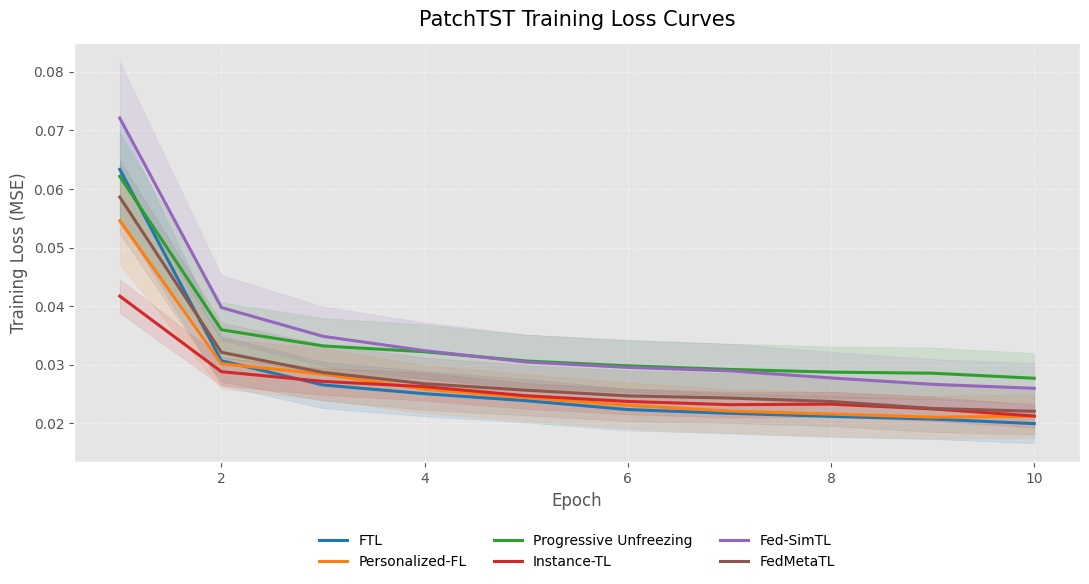

In [ ]:
# Loss-curve figure for PatchTST (6 strategies)
import numpy as np
import matplotlib.pyplot as plt

order = ['FTL','Personalized-FL','Progressive Unfreezing','Instance-TL','Fed-SimTL','FedMetaTL']
colors = {
    'FTL':'#1f77b4',
    'Personalized-FL':'#ff7f0e',
    'Progressive Unfreezing':'#2ca02c',
    'Instance-TL':'#d62728',
    'Fed-SimTL':'#9467bd',
    'FedMetaTL':'#8c564b'
}

def canonical_patchtst_strategy_name(name):
    s = str(name)

    # remove numeric prefix, e.g. "1. FTL" -> "FTL"
    if ". " in s:
        s = s.split(". ", 1)[1]

    # remove common PatchTST labels
    s = s.replace("PatchTST All6 ", "")
    s = s.replace("PatchTST ", "")
    s = s.replace("-PatchTST", "")
    s = s.strip()

    mapping = {
        "Progressive": "Progressive Unfreezing",
        "Progressive-LSTM": "Progressive Unfreezing",
        "FedMetaTL": "FedMetaTL",
        "Meta-FT": "FedMetaTL",
        "Fed-SimTL": "Fed-SimTL",
        "Instance-TL": "Instance-TL",
        "Personalized-FL": "Personalized-FL",
        "FTL": "FTL",
    }

    return mapping.get(s, s)

grouped = {}

for e in PATCHTST_LOSS_CURVES:
    raw_name = e.get("strategy") or e.get("name") or "Unknown"
    s = canonical_patchtst_strategy_name(raw_name)

    if s in {
        "Unknown",
        "meta-inner",
        "Pretrain",
        "Pretrain-PatchTST",
        "Local-only",
        "FedAvg (No Pretrain)",
        "Centralized",
    }:
        continue

    train_loss = e.get("train_loss", [])
    if not isinstance(train_loss, (list, tuple)) or len(train_loss) == 0:
        continue

    if s in order:
        grouped.setdefault(s, []).append(np.asarray(train_loss, dtype=float))

print("Curves found:", {k: len(v) for k, v in grouped.items()})

plt.style.use("ggplot")
fig, ax = plt.subplots(figsize=(11, 6))

for s in [x for x in order if x in grouped]:
    curves = [c for c in grouped[s] if len(c) > 0]
    if not curves:
        continue

    mlen = max(len(c) for c in curves)
    mat = np.vstack([np.pad(c, (0, mlen - len(c)), mode="edge") for c in curves])
    mean = mat.mean(axis=0)
    std = mat.std(axis=0) * 0.15
    x = np.arange(1, len(mean) + 1)

    ax.plot(x, mean, lw=2.2, color=colors[s], label=s)
    ax.fill_between(x, mean - std, mean + std, color=colors[s], alpha=0.12)

ax.set_title("PatchTST Training Loss Curves", fontsize=15, pad=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss (MSE)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig(f"patchtst_loss_curves_all6_seed{int(SEED)}.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Export PatchTST early-stopping metadata for seed-sensitivity plots
from pathlib import Path
import numpy as np
import pandas as pd

RESULTS_DIR = Path("saved_results")
RESULTS_DIR.mkdir(exist_ok=True)

if "PATCHTST_LOSS_CURVES" not in globals() or not isinstance(PATCHTST_LOSS_CURVES, list) or len(PATCHTST_LOSS_CURVES) == 0:
    raise RuntimeError(
        "PATCHTST_LOSS_CURVES is empty. Not overwriting early-stopping CSV. "
        "Run training first or load saved full loss curves before exporting."
    )

def _canonical_patchtst_early_strategy(name):
    s = str(name)
    if ". " in s:
        s = s.split(". ", 1)[1]
    s = s.replace("PatchTST All6 ", "")
    s = s.replace("PatchTST ", "")
    s = s.replace("-PatchTST", "").strip()
    mapping = {
        "FTL": "1. FTL",
        "Personalized-FL": "2. Personalized-FL",
        "Progressive": "3. Progressive Unfreezing",
        "Progressive Unfreezing": "3. Progressive Unfreezing",
        "Instance-TL": "4. Instance-TL",
        "Fed-SimTL": "5. Fed-SimTL",
        "FedMetaTL": "6. FedMetaTL",
        "Meta-FT": "6. FedMetaTL",
        "FedAvg (No Pretrain)": "1b. FedAvg (No Pretrain)",
        "FedAvg-NoPretrain": "1b. FedAvg (No Pretrain)",
        "Local-only": "0. Local-only",
        "Centralized": "C. Centralized",
    }
    return mapping.get(s, s)

def _last_finite(values):
    vals = [float(v) for v in values if pd.notna(v)]
    return vals[-1] if vals else np.nan

def _best_finite(values):
    vals = [float(v) for v in values if pd.notna(v)]
    return min(vals) if vals else np.nan

early_rows = []
for i, h in enumerate(globals().get("PATCHTST_LOSS_CURVES", [])):
    if not isinstance(h, dict):
        continue
    train_loss = h.get("train_loss", []) or []
    val_loss = h.get("val_loss", []) or []
    raw_strategy = h.get("strategy") or h.get("name") or "Unknown"
    epochs_ran = int(h.get("epochs_ran", len(train_loss)))
    requested_epochs = h.get("requested_epochs", h.get("epochs_requested", np.nan))
    stopped_early = h.get("stopped_early", np.nan)
    if pd.isna(stopped_early) and pd.notna(requested_epochs):
        stopped_early = bool(epochs_ran < int(requested_epochs))
    early_rows.append({
        "model": "PatchTST",
        "seed": int(SEED),
        "curve_index": i,
        "strategy_raw": raw_strategy,
        "strategy": _canonical_patchtst_early_strategy(raw_strategy),
        "epochs_ran": epochs_ran,
        "requested_epochs": requested_epochs,
        "stopped_early": stopped_early,
        "final_train_loss": _last_finite(train_loss),
        "final_val_loss": _last_finite(val_loss),
        "best_val_loss": _best_finite(val_loss),
        "n_train_points": len(train_loss),
        "n_val_points": len(val_loss),
    })

patchtst_early_stopping_df = pd.DataFrame(early_rows)
if patchtst_early_stopping_df.empty:
    raise RuntimeError(
        "No valid PatchTST early-stopping rows were collected. "
        "Not overwriting early-stopping CSV."
    )
out_path = RESULTS_DIR / f"patchtst_early_stopping_seed{int(SEED)}.csv"
patchtst_early_stopping_df.to_csv(out_path, index=False)
display(patchtst_early_stopping_df)
print("Saved:", out_path)
print("Rows:", len(patchtst_early_stopping_df))


,model,seed,curve_index,strategy_raw,strategy,epochs_ran,requested_epochs,stopped_early,final_train_loss,final_val_loss,best_val_loss,n_train_points,n_val_points
0,PatchTST,123,0,Pretrain-PatchTST,Pretrain,5,NaN,NaN,0.058290,NaN,NaN,5,5
1,PatchTST,123,1,FTL,1. FTL,10,NaN,NaN,0.012139,0.013114,0.011252,10,10
2,PatchTST,123,2,FTL,1. FTL,10,NaN,NaN,0.023238,0.015531,0.015531,10,10
3,PatchTST,123,3,FTL,1. FTL,10,NaN,NaN,0.022960,0.092939,0.081325,10,10
4,PatchTST,123,4,FTL,1. FTL,10,NaN,NaN,0.010964,0.049716,0.049716,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,PatchTST,123,1592,FedMetaTL,6. FedMetaTL,10,NaN,NaN,0.039163,0.080899,0.070288,10,10
1593,PatchTST,123,1593,FedMetaTL,6. FedMetaTL,10,NaN,NaN,0.015059,0.350979,0.081213,10,10
1594,PatchTST,123,1594,FedMetaTL,6. FedMetaTL,10,NaN,NaN,0.007069,0.016271,0.016271,10,10
1595,PatchTST,123,1595,FedMetaTL,6. FedMetaTL,10,NaN,NaN,0.080414,1.624322,1.318901,10,10


Saved: saved_results\patchtst_early_stopping_seed123.csv
Rows: 1597


In [ ]:
# Standardized export for multi-seed aggregation (PatchTST)
from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path('saved_results')
RESULTS_DIR.mkdir(exist_ok=True)

def _metric(df, col):
    return float(df[col].mean()) if isinstance(df, pd.DataFrame) and len(df) and col in df.columns else np.nan

def _metric_split(df, mask, col='mae'):
    if not isinstance(df, pd.DataFrame) or len(df) == 0 or col not in df.columns:
        return np.nan
    d = df[mask]
    return float(d[col].mean()) if len(d) else np.nan

strategy_frames = {
    '0. Local-only': globals().get('df_local_patchtst'),
    '1b. FedAvg (No Pretrain)': globals().get('df_scratch_patchtst'),
    'C. Centralized': globals().get('df_central_patchtst'),
}

if 'all_results' in globals() and isinstance(all_results, pd.DataFrame) and len(all_results) > 0:
    mapping = {
        'Local-only': '0. Local-only',
        'FedAvg (No Pretrain)': '1b. FedAvg (No Pretrain)',
        'Centralized': 'C. Centralized',
        'FTL': '1. FTL',
        'Personalized-FL': '2. Personalized-FL',
        'Progressive Unfreezing': '3. Progressive Unfreezing',
        'Instance-TL': '4. Instance-TL',
        'Fed-SimTL': '5. Fed-SimTL',
        'FedMetaTL': '6. FedMetaTL',
    }
    for raw, display_name in mapping.items():
        d = all_results[all_results['Strategy'] == raw].copy()
        if len(d):
            strategy_frames[display_name] = d

rows = []
for strategy, df_res in strategy_frames.items():
    if not isinstance(df_res, pd.DataFrame) or df_res.empty or 'cold_start' not in df_res.columns:
        continue
    rows.append({
        'model': 'PatchTST',
        'seed': int(SEED),
        'strategy': strategy,
        'overall_mae': _metric(df_res, 'mae'),
        'warm_mae': _metric_split(df_res, ~df_res['cold_start'], 'mae'),
        'cold_mae': _metric_split(df_res, df_res['cold_start'], 'mae'),
        'overall_cvrmse': _metric(df_res, 'cvrmse'),
        'overall_wape': _metric(df_res, 'wape'),
    })

seed_summary_patchtst = pd.DataFrame(rows).sort_values('overall_mae').reset_index(drop=True)
out_path = RESULTS_DIR / f'patchtst_seed_{int(SEED)}_summary.csv'
seed_summary_patchtst.to_csv(out_path, index=False)
print('Saved:', out_path)
display(seed_summary_patchtst)


Saved: saved_results\patchtst_seed_123_summary.csv


,model,seed,strategy,overall_mae,warm_mae,cold_mae,overall_cvrmse,overall_wape
0,PatchTST,123,C. Centralized,19.515747,17.727089,26.670379,29.808838,24.163195
1,PatchTST,123,0. Local-only,32.171827,24.773507,61.765109,34.846642,26.989286
2,PatchTST,123,2. Personalized-FL,36.189131,21.106261,96.520611,41.891605,37.186283
3,PatchTST,123,5. Fed-SimTL,48.529742,42.824069,71.352435,77.721489,72.999672
4,PatchTST,123,3. Progressive Unfreezing,65.066794,59.679998,86.613975,63.190041,57.849564
5,PatchTST,123,6. FedMetaTL,65.338018,58.655160,92.069449,77.071571,71.787834
6,PatchTST,123,1. FTL,69.412360,63.392644,93.491224,68.478973,63.605312
7,PatchTST,123,4. Instance-TL,69.525614,61.462070,101.779789,74.347916,68.940773
8,PatchTST,123,1b. FedAvg (No Pretrain),85.165156,76.476383,119.920250,163.087341,157.734421


In [ ]:
# COLD-START DAYS SENSITIVITY (FTL BASELINE - PatchTST)
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DAYS_SWEEP = [3, 7, 14, 21, 30, 45, 60]
MIN_TRAIN_ROWS_COLD = max(LOOKBACK + HORIZON + 1, int(globals().get("MIN_TRAIN_ROWS_COLD", LOOKBACK + HORIZON + 1)))

_cold_bids_for_sweep = set(globals().get("cold_bids", globals().get("cold_set", set())))
_split_backup = {
    bid: {
        "train_end": int(client_data[bid]["train_end"]),
        "val_end": int(client_data[bid]["val_end"]),
        "train_orig_end": int(client_data[bid].get("train_orig_end", client_data[bid]["train_end"])),
        "cold_start": bool(client_data[bid].get("cold_start", bid in _cold_bids_for_sweep)),
    }
    for bid in client_data
}

def _apply_patchtst_cold_days(days):
    for bid in _cold_bids_for_sweep:
        if bid not in client_data:
            continue
        full = client_data[bid]["full"]
        original_train_end = _split_backup[bid].get("train_orig_end", _split_backup[bid]["train_end"])
        val_end = _split_backup[bid]["val_end"]

        if "timestamp" in full.columns:
            start = full["timestamp"].min()
            proposed_train_end = int((full["timestamp"] < (start + pd.Timedelta(days=days))).sum())
        else:
            proposed_train_end = int(days * 24)

        proposed_train_end = max(MIN_TRAIN_ROWS_COLD, proposed_train_end)
        proposed_train_end = min(proposed_train_end, original_train_end, val_end - HORIZON - 1)

        client_data[bid]["train_end"] = proposed_train_end
        client_data[bid]["val_end"] = val_end
        client_data[bid]["cold_start"] = True

def _restore_patchtst_splits():
    for bid, parts in _split_backup.items():
        if bid in client_data:
            client_data[bid]["train_end"] = parts["train_end"]
            client_data[bid]["val_end"] = parts["val_end"]
            client_data[bid]["train_orig_end"] = parts.get("train_orig_end", parts["train_end"])
            client_data[bid]["cold_start"] = parts["cold_start"]

def _run_patchtst_ftl_once_for_current_splits():
    weights = [w.copy() for w in pretrain_weights]
    k = max(2, int(len(usable_bids) * SAMPLE_FRAC))

    for _ in range(ROUNDS):
        sampled = random.sample(list(usable_bids), k)
        local_ws = []
        for bid in sampled:
            tr, va, _ = loaders_for_bid(bid)
            if len(tr.dataset) == 0:
                continue
            m = make_model()
            set_weights(m, weights)
            train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST FTL cold-days sensitivity")
            local_ws.append(get_weights(m))
        if local_ws:
            weights = average_weights(local_ws)

    return eval_strategy(weights, "FTL cold-days sensitivity")

out_path = RESULTS_DIR / f"patchtst_cold_days_sensitivity_ftl_seed{int(SEED)}.csv"

if should_load_existing(out_path):
    patchtst_cold_days_sensitivity_df = pd.read_csv(out_path).sort_values("days").reset_index(drop=True)
    if "metric_scale" in patchtst_cold_days_sensitivity_df.columns and (patchtst_cold_days_sensitivity_df["metric_scale"] == PATCHTST_METRIC_SCALE).all():
        print("Loaded cold-start sensitivity from disk:", out_path)
    else:
        print("Existing cold-start sensitivity uses raw-scale MAE; recomputing log-scale metrics:", out_path)
        patchtst_cold_days_sensitivity_df = pd.DataFrame()
if not isinstance(globals().get("patchtst_cold_days_sensitivity_df"), pd.DataFrame) or patchtst_cold_days_sensitivity_df.empty:
    sensitivity_rows = []
    try:
        for days in DAYS_SWEEP:
            np.random.seed(SEED)
            random.seed(SEED)
            torch.manual_seed(SEED)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(SEED)

            _apply_patchtst_cold_days(days)
            df_day = _run_patchtst_ftl_once_for_current_splits()

            warm = df_day[~df_day["cold_start"]]
            cold = df_day[df_day["cold_start"]]

            sensitivity_rows.append({
                "days": days,
                "metric_scale": PATCHTST_METRIC_SCALE,
                "overall_mae_log": df_day["mae"].mean(),
                "warm_mae_log": warm["mae"].mean(),
                "cold_mae_log": cold["mae"].mean(),
                "overall_cvrmse_raw": df_day["cvrmse"].mean(),
                "cold_cvrmse_raw": cold["cvrmse"].mean(),
                "overall_wape_raw": df_day["wape"].mean(),
                "cold_wape_raw": cold["wape"].mean(),
                "cold_train_rows_min": min(client_data[bid]["train_end"] for bid in _cold_bids_for_sweep if bid in client_data),
                "cold_train_rows_mean": np.mean([client_data[bid]["train_end"] for bid in _cold_bids_for_sweep if bid in client_data]),
            })
    finally:
        _restore_patchtst_splits()

    patchtst_cold_days_sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values("days").reset_index(drop=True)
    patchtst_cold_days_sensitivity_df.to_csv(out_path, index=False)
    print("Saved:", out_path)

cold_days_sensitivity_df = patchtst_cold_days_sensitivity_df
display(patchtst_cold_days_sensitivity_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(patchtst_cold_days_sensitivity_df["days"], patchtst_cold_days_sensitivity_df["overall_mae_log"], marker="o", label="Overall")
axes[0].plot(patchtst_cold_days_sensitivity_df["days"], patchtst_cold_days_sensitivity_df["cold_mae_log"], marker="o", label="Cold-start")
axes[0].set_title("PatchTST FTL: MAE vs Cold-Train Days")
axes[0].set_xlabel("Cold-start train days")
axes[0].set_ylabel("MAE (log)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(patchtst_cold_days_sensitivity_df["days"], patchtst_cold_days_sensitivity_df["overall_wape_raw"], marker="o", label="Overall")
axes[1].plot(patchtst_cold_days_sensitivity_df["days"], patchtst_cold_days_sensitivity_df["cold_wape_raw"], marker="o", label="Cold-start")
axes[1].set_title("PatchTST FTL: WAPE vs Cold-Train Days")
axes[1].set_xlabel("Cold-start train days")
axes[1].set_ylabel("WAPE (raw %)")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(patchtst_cold_days_sensitivity_df["days"], patchtst_cold_days_sensitivity_df["overall_cvrmse_raw"], marker="o", label="Overall")
axes[2].plot(patchtst_cold_days_sensitivity_df["days"], patchtst_cold_days_sensitivity_df["cold_cvrmse_raw"], marker="o", label="Cold-start")
axes[2].set_title("PatchTST FTL: CVRMSE vs Cold-Train Days")
axes[2].set_xlabel("Cold-start train days")
axes[2].set_ylabel("CVRMSE (raw %)")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# COLD-START DAYS SENSITIVITY (ALL 6 STRATEGIES - PatchTST)
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DAYS_SWEEP_ALL6 = [3, 7, 14, 21, 30, 45, 60]
patchtst_cold_days_all6_path = RESULTS_DIR / f"patchtst_cold_days_all6_seed{int(SEED)}.csv"

def _metric_row_patchtst(days, strategy, df_eval):
    warm = df_eval[~df_eval["cold_start"]]
    cold = df_eval[df_eval["cold_start"]]
    return {
        "days": int(days),
        "strategy": strategy,
        "metric_scale": PATCHTST_METRIC_SCALE,
        "overall_mae_log": float(df_eval["mae"].mean()),
        "warm_mae_log": float(warm["mae"].mean()) if len(warm) else np.nan,
        "cold_mae_log": float(cold["mae"].mean()) if len(cold) else np.nan,
        "overall_cvrmse_raw": float(df_eval["cvrmse"].mean()),
        "cold_cvrmse_raw": float(cold["cvrmse"].mean()) if len(cold) else np.nan,
        "overall_wape_raw": float(df_eval["wape"].mean()),
        "cold_wape_raw": float(cold["wape"].mean()) if len(cold) else np.nan,
    }

def _eval_personalized_patchtst_for_sweep(global_enc, pers_heads):
    rows = []
    fallback_head = list(pers_heads.values())[0]
    for bid in usable_bids:
        _, _, te = loaders_for_bid(bid)
        head = pers_heads.get(bid, fallback_head)
        w = merge_encoder_head(global_enc, head)
        m = make_model(); set_weights(m, w)
        mae, rmse, cvrmse, wape = eval_model(m, te)
        rows.append({"Strategy": "2. Personalized-FL", "building_id": bid, "cold_start": bid in cold_bids, "mae": mae, "rmse": rmse, "cvrmse": cvrmse, "wape": wape, "metric_scale": PATCHTST_METRIC_SCALE})
    return pd.DataFrame(rows)

if should_load_existing(patchtst_cold_days_all6_path):
    patchtst_cold_days_all6_df = pd.read_csv(patchtst_cold_days_all6_path).sort_values(["days", "strategy"]).reset_index(drop=True)
    if "metric_scale" in patchtst_cold_days_all6_df.columns and (patchtst_cold_days_all6_df["metric_scale"] == PATCHTST_METRIC_SCALE).all():
        print("Loaded all-strategy cold-start sweep:", patchtst_cold_days_all6_path)
    else:
        print("Existing all-strategy cold-start sweep uses raw-scale MAE; recomputing log-scale metrics:", patchtst_cold_days_all6_path)
        patchtst_cold_days_all6_df = pd.DataFrame()
if not isinstance(globals().get("patchtst_cold_days_all6_df"), pd.DataFrame) or patchtst_cold_days_all6_df.empty:
    sweep_rows_all6 = []
    try:
        for days in DAYS_SWEEP_ALL6:
            print(f"\n[PatchTST All6 Sweep] days={days}")
            np.random.seed(SEED)
            random.seed(SEED)
            torch.manual_seed(SEED)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(SEED)
            _restore_patchtst_splits()
            _apply_patchtst_cold_days(days)

            k = max(2, int(len(usable_bids) * SAMPLE_FRAC))

            # Strategy 1: FTL
            w1 = [w.copy() for w in pretrain_weights]
            for _ in range(ROUNDS):
                sampled = random.sample(list(usable_bids), k)
                local_ws = []
                for bid in sampled:
                    tr, va, _ = loaders_for_bid(bid)
                    if len(tr.dataset) == 0:
                        continue
                    m = make_model(); set_weights(m, w1)
                    train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST All6 FTL")
                    local_ws.append(get_weights(m))
                if local_ws:
                    w1 = average_weights(local_ws)
            sweep_rows_all6.append(_metric_row_patchtst(days, "1. FTL", eval_strategy(w1, "1. FTL")))

            # Strategy 2: Personalized-FL
            global_enc_s, base_head_s = split_encoder_head(pretrain_weights)
            pers_heads_s = {bid: base_head_s for bid in usable_bids}
            for _ in range(ROUNDS):
                sampled = random.sample(list(usable_bids), k)
                enc_updates = []
                for bid in sampled:
                    tr, va, _ = loaders_for_bid(bid)
                    m = make_model(); set_weights(m, merge_encoder_head(global_enc_s, pers_heads_s[bid]))
                    train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST All6 Personalized-FL")
                    e, h = split_encoder_head(get_weights(m))
                    enc_updates.append(e); pers_heads_s[bid] = h
                if enc_updates:
                    global_enc_s = average_weights(enc_updates)
            sweep_rows_all6.append(_metric_row_patchtst(days, "2. Personalized-FL", _eval_personalized_patchtst_for_sweep(global_enc_s, pers_heads_s)))

            # Strategy 3: Progressive Unfreezing
            w3 = [w.copy() for w in pretrain_weights]
            frozen_rounds = max(1, ROUNDS // 3)
            for r in range(ROUNDS):
                sampled = random.sample(list(usable_bids), k)
                local_ws = []
                for bid in sampled:
                    tr, va, _ = loaders_for_bid(bid)
                    m = make_model(); set_weights(m, w3)
                    train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, freeze_encoder=(r < frozen_rounds), record_name="PatchTST All6 Progressive")
                    local_ws.append(get_weights(m))
                if local_ws:
                    w3 = average_weights(local_ws)
            sweep_rows_all6.append(_metric_row_patchtst(days, "3. Progressive Unfreezing", eval_strategy(w3, "3. Progressive Unfreezing")))

            # Strategy 4: Instance-TL
            w4 = [w.copy() for w in pretrain_weights]
            for _ in range(ROUNDS):
                sampled = random.sample(list(usable_bids), k)
                local_ws = []
                for bid in sampled:
                    tr_aug = augmented_loader_for_bid(bid)
                    _, va, _ = loaders_for_bid(bid)
                    m = make_model(); set_weights(m, w4)
                    train_one(m, tr_aug, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST All6 Instance-TL")
                    local_ws.append(get_weights(m))
                if local_ws:
                    w4 = average_weights(local_ws)
            sweep_rows_all6.append(_metric_row_patchtst(days, "4. Instance-TL", eval_strategy(w4, "4. Instance-TL")))

            # Strategy 5: Fed-SimTL
            w5 = [w.copy() for w in pretrain_weights]
            for _ in range(ROUNDS):
                sampled = random.sample(list(usable_bids), k)
                local_ws, local_sc = [], []
                for bid in sampled:
                    tr, va, _ = loaders_for_bid(bid)
                    m = make_model(); set_weights(m, w5)
                    train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST All6 Fed-SimTL")
                    local_ws.append(get_weights(m))
                    local_sc.append(sim_matrix.get(bid, {}).get(bid, 1.0))
                if local_ws:
                    w5 = weighted_average_weights(local_ws, local_sc)
            sweep_rows_all6.append(_metric_row_patchtst(days, "5. Fed-SimTL", eval_strategy(w5, "5. Fed-SimTL")))

            # Strategy 6: FedMetaTL
            meta_w = [w.copy() for w in pretrain_weights]
            meta_rounds = globals().get("META_ROUNDS", 5)
            meta_step = globals().get("META_STEP", 0.2)
            k_meta = max(2, int(len(source_bids) * SAMPLE_FRAC))
            for _ in range(meta_rounds):
                sampled = random.sample(list(source_bids), k_meta)
                locals_w = []
                for bid in sampled:
                    tr, va, _ = loaders_for_bid(bid)
                    m = make_model(); set_weights(m, meta_w)
                    train_one(m, tr, epochs=2, lr=LR, val_loader=va, record_name="PatchTST All6 meta-inner")
                    locals_w.append(get_weights(m))
                if locals_w:
                    mean_w = average_weights(locals_w)
                    meta_w = [w + meta_step * (mw - w) for w, mw in zip(meta_w, mean_w)]
            w6 = meta_w
            for _ in range(ROUNDS):
                sampled = random.sample(list(usable_bids), k)
                local_ws = []
                for bid in sampled:
                    tr, va, _ = loaders_for_bid(bid)
                    m = make_model(); set_weights(m, w6)
                    train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST All6 FedMetaTL")
                    local_ws.append(get_weights(m))
                if local_ws:
                    w6 = average_weights(local_ws)
            sweep_rows_all6.append(_metric_row_patchtst(days, "6. FedMetaTL", eval_strategy(w6, "6. FedMetaTL")))
    finally:
        _restore_patchtst_splits()

    patchtst_cold_days_all6_df = pd.DataFrame(sweep_rows_all6).sort_values(["days", "strategy"]).reset_index(drop=True)
    patchtst_cold_days_all6_df.to_csv(patchtst_cold_days_all6_path, index=False)
    print("Saved all-strategy cold-start sweep:", patchtst_cold_days_all6_path)

display(patchtst_cold_days_all6_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for strategy in sorted(patchtst_cold_days_all6_df["strategy"].unique()):
    d = patchtst_cold_days_all6_df[patchtst_cold_days_all6_df["strategy"] == strategy].sort_values("days")
    axes[0].plot(d["days"], d["cold_mae_log"], marker="o", label=strategy)
    axes[1].plot(d["days"], d["cold_wape_raw"], marker="o", label=strategy)
    axes[2].plot(d["days"], d["cold_cvrmse_raw"], marker="o", label=strategy)

axes[0].set_title("PatchTST: Cold-start MAE vs Days")
axes[0].set_xlabel("Cold-start train days")
axes[0].set_ylabel("MAE (log)")
axes[1].set_title("PatchTST: Cold-start WAPE vs Days")
axes[1].set_xlabel("Cold-start train days")
axes[1].set_ylabel("WAPE (raw %)")
axes[2].set_title("PatchTST: Cold-start CVRMSE vs Days")
axes[2].set_xlabel("Cold-start train days")
axes[2].set_ylabel("CVRMSE (raw %)")
for ax in axes:
    ax.grid(alpha=0.3)
handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()


In [ ]:
# Save benchmark timing table (PatchTST)
from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path("saved_results")
RESULTS_DIR.mkdir(exist_ok=True)

def _canonical_benchmark_strategy(raw):
    s = str(raw)
    for token in ["-PatchTST", "-MLP", "-LSTM", "-PatchTST"]:
        s = s.replace(token, "")
    s = s.replace("Scratch FedAvg", "FedAvg")
    checks = [
        ("Local-only", "0. Local-only"),
        ("FedAvg", "1b. FedAvg (No Pretrain)"),
        ("Centralized", "C. Centralized"),
        ("Personalized", "2. Personalized-FL"),
        ("Pers-FL", "2. Personalized-FL"),
        ("Progressive", "3. Progressive Unfreezing"),
        ("Prog", "3. Progressive Unfreezing"),
        ("Instance", "4. Instance-TL"),
        ("Fed-SimTL", "5. Fed-SimTL"),
        ("FedMeta", "6. FedMetaTL"),
        ("Meta", "6. FedMetaTL"),
        ("FTL", "1. FTL"),
    ]
    for needle, canonical in checks:
        if needle.lower() in s.lower():
            return canonical
    return s

runtime_log = globals().get("strategy_runtime_patchtst", {})
benchmark_rows = []

sample_base = len(globals().get("source_bids", [])) or len(globals().get("usable_bids", []))
sample_frac = globals().get("SAMPLE_FRAC", np.nan)
sampled_clients = max(2, int(sample_base * float(sample_frac))) if sample_base and pd.notna(sample_frac) else np.nan

for raw_strategy, rec in runtime_log.items():
    if not isinstance(rec, dict):
        continue
    train_sec = float(rec.get("train_sec", 0.0))
    eval_sec = float(rec.get("eval_sec", 0.0))
    benchmark_rows.append({
        "model": "PatchTST",
        "seed": int(globals().get("SEED", -1)),
        "raw_strategy": raw_strategy,
        "strategy": _canonical_benchmark_strategy(raw_strategy),
        "train_time_sec": train_sec,
        "eval_time_sec": eval_sec,
        "total_time_sec": train_sec + eval_sec,
        "train_calls": int(rec.get("train_calls", 0)),
        "eval_calls": int(rec.get("eval_calls", 0)),
        "rounds": globals().get("ROUNDS", np.nan),
        "local_epochs": globals().get("LOCAL_EPOCHS", np.nan),
        "sample_frac": sample_frac,
        "sampled_clients_per_round": sampled_clients,
        "source_clients": len(globals().get("source_bids", [])),
        "usable_clients": len(globals().get("usable_bids", [])),
    })

benchmark_times_patchtst = pd.DataFrame(benchmark_rows)
if not benchmark_times_patchtst.empty:
    benchmark_times_patchtst = (
        benchmark_times_patchtst
        .groupby(["model", "seed", "strategy"], as_index=False)
        .agg({
            "raw_strategy": lambda x: "; ".join(sorted(set(map(str, x)))),
            "train_time_sec": "sum",
            "eval_time_sec": "sum",
            "total_time_sec": "sum",
            "train_calls": "sum",
            "eval_calls": "sum",
            "rounds": "first",
            "local_epochs": "first",
            "sample_frac": "first",
            "sampled_clients_per_round": "first",
            "source_clients": "first",
            "usable_clients": "first",
        })
        .sort_values("total_time_sec", ascending=False)
        .reset_index(drop=True)
    )

out_path = RESULTS_DIR / f"patchtst_benchmark_times_seed{int(globals().get('SEED', -1))}.csv"
if out_path.exists():
    existing_benchmark = pd.read_csv(out_path)
    if not existing_benchmark.empty:
        existing_benchmark["__source_order"] = 0
        benchmark_times_patchtst["__source_order"] = 1
        benchmark_times_patchtst = pd.concat([existing_benchmark, benchmark_times_patchtst], ignore_index=True, sort=False)
        benchmark_times_patchtst["__has_train_time"] = (
            pd.to_numeric(benchmark_times_patchtst["train_time_sec"], errors="coerce").fillna(0) > 0
        ) & (
            pd.to_numeric(benchmark_times_patchtst["train_calls"], errors="coerce").fillna(0) > 0
        )
        benchmark_times_patchtst = (
            benchmark_times_patchtst
            .sort_values(["strategy", "__has_train_time", "__source_order"])
            .drop_duplicates(["model", "seed", "strategy"], keep="last")
            .drop(columns=["__source_order", "__has_train_time"], errors="ignore")
            .sort_values("total_time_sec", ascending=False)
            .reset_index(drop=True)
        )
benchmark_times_patchtst.to_csv(out_path, index=False)
print("Saved benchmark times:", out_path)
display(benchmark_times_patchtst)

In [ ]:
# PRETRAINING FRACTION SWEEP (ALL 6 STRATEGIES - PatchTST)
# Expensive: run only when you need resource-allocation thresholds for every strategy.
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRETRAIN_FRACS_PATCHTST_ALL6 = [0.10, 0.25, 0.50, 0.75, 1.00]
PATCHTST_PRETRAIN_SWEEP_STRATEGIES = [
    "1. FTL",
    "2. Personalized-FL",
    "3. Progressive Unfreezing",
    "4. Instance-TL",
    "5. Fed-SimTL",
    "6. FedMetaTL",
]
patchtst_pretrain_sweep_all6_path = RESULTS_DIR / f"patchtst_pretrain_sweep_all6_seed{int(SEED)}.csv"

def _pooled_loader_for_source_frac_patchtst_all6(frac, batch=BATCH_SIZE):
    if callable(globals().get("_pooled_loader_for_source_frac_patchtst")):
        return _pooled_loader_for_source_frac_patchtst(frac, batch=batch)
    Xs, ys = [], []
    for bid in source_bids:
        Xtr, ytr, _, _, _, _ = split_windows_for_bid(bid)
        if len(Xtr) > 0:
            Xs.append(Xtr)
            ys.append(ytr)
    if not Xs:
        raise RuntimeError("No PatchTST source pretraining windows available.")
    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    n = max(1, int(len(X) * float(frac)))
    rng = np.random.default_rng(SEED + int(round(float(frac) * 1000)))
    idx = rng.choice(len(X), size=n, replace=False)
    return DataLoader(SeqDataset(X[idx], y[idx]), batch_size=batch, shuffle=True), n

def _patchtst_sweep_metrics_all6(df_eval):
    if callable(globals().get("_patchtst_sweep_metrics")):
        return _patchtst_sweep_metrics(df_eval)
    warm = df_eval[~df_eval["cold_start"]]
    cold = df_eval[df_eval["cold_start"]]
    return {
        "overall_mae": float(df_eval["mae"].mean()),
        "warm_mae": float(warm["mae"].mean()) if len(warm) else np.nan,
        "cold_mae": float(cold["mae"].mean()) if len(cold) else np.nan,
        "cvrmse": float(df_eval["cvrmse"].mean()),
        "wape": float(df_eval["wape"].mean()),
    }

def _eval_personalized_patchtst_for_pretrain_sweep(global_enc, pers_heads):
    rows = []
    fallback_head = list(pers_heads.values())[0]
    for bid in usable_bids:
        _, _, te = loaders_for_bid(bid)
        head = pers_heads.get(bid, fallback_head)
        m = make_model()
        set_weights(m, merge_encoder_head(global_enc, head))
        mae, rmse, cvrmse, wape = eval_model(m, te)
        rows.append({
            "Strategy": "2. Personalized-FL",
            "building_id": bid,
            "cold_start": bid in cold_bids,
            "mae": mae,
            "rmse": rmse,
            "cvrmse": cvrmse,
            "wape": wape,
        })
    return pd.DataFrame(rows)

def _run_patchtst_strategy_for_pretrain_sweep(strategy, base_weights):
    k = max(2, int(len(source_bids) * SAMPLE_FRAC))

    if strategy == "1. FTL":
        weights = [w.copy() for w in base_weights]
        for _ in range(ROUNDS):
            sampled = random.sample(list(source_bids), k)
            local_ws = []
            for bid in sampled:
                tr, va, _ = loaders_for_bid(bid)
                if len(tr.dataset) == 0:
                    continue
                m = make_model(); set_weights(m, weights)
                train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST All6 pretrain-sweep FTL")
                local_ws.append(get_weights(m))
            if local_ws:
                weights = average_weights(local_ws)
        return eval_strategy(weights, strategy)

    if strategy == "2. Personalized-FL":
        global_enc, base_head = split_encoder_head(base_weights)
        pers_heads = {bid: base_head for bid in source_bids}
        for _ in range(ROUNDS):
            sampled = random.sample(list(source_bids), k)
            enc_updates = []
            for bid in sampled:
                tr, va, _ = loaders_for_bid(bid)
                if len(tr.dataset) == 0:
                    continue
                m = make_model(); set_weights(m, merge_encoder_head(global_enc, pers_heads[bid]))
                train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST All6 pretrain-sweep Personalized-FL")
                enc_w, head_w = split_encoder_head(get_weights(m))
                enc_updates.append(enc_w)
                pers_heads[bid] = head_w
            if enc_updates:
                global_enc = average_weights(enc_updates)
        return _eval_personalized_patchtst_for_pretrain_sweep(global_enc, pers_heads)

    if strategy == "3. Progressive Unfreezing":
        weights = [w.copy() for w in base_weights]
        frozen_rounds = max(1, ROUNDS // 3)
        for r in range(ROUNDS):
            sampled = random.sample(list(source_bids), k)
            local_ws = []
            for bid in sampled:
                tr, va, _ = loaders_for_bid(bid)
                if len(tr.dataset) == 0:
                    continue
                m = make_model(); set_weights(m, weights)
                train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, freeze_encoder=(r < frozen_rounds), record_name="PatchTST All6 pretrain-sweep Progressive")
                local_ws.append(get_weights(m))
            if local_ws:
                weights = average_weights(local_ws)
        return eval_strategy(weights, strategy)

    if strategy == "4. Instance-TL":
        weights = [w.copy() for w in base_weights]
        for _ in range(ROUNDS):
            sampled = random.sample(list(source_bids), k)
            local_ws = []
            for bid in sampled:
                tr_aug = augmented_loader_for_bid(bid)
                _, va, _ = loaders_for_bid(bid)
                if len(tr_aug.dataset) == 0:
                    continue
                m = make_model(); set_weights(m, weights)
                train_one(m, tr_aug, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST All6 pretrain-sweep Instance-TL")
                local_ws.append(get_weights(m))
            if local_ws:
                weights = average_weights(local_ws)
        return eval_strategy(weights, strategy)

    if strategy == "5. Fed-SimTL":
        weights = [w.copy() for w in base_weights]
        for _ in range(ROUNDS):
            sampled = random.sample(list(source_bids), k)
            local_ws, local_sc = [], []
            for bid in sampled:
                tr, va, _ = loaders_for_bid(bid)
                if len(tr.dataset) == 0:
                    continue
                m = make_model(); set_weights(m, weights)
                train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST All6 pretrain-sweep Fed-SimTL")
                local_ws.append(get_weights(m))
                local_sc.append(sim_matrix.get(bid, {}).get(bid, 1.0))
            if local_ws:
                weights = weighted_average_weights(local_ws, local_sc)
        return eval_strategy(weights, strategy)

    if strategy == "6. FedMetaTL":
        meta_weights = [w.copy() for w in base_weights]
        meta_rounds = globals().get("META_ROUNDS", 5)
        meta_step = globals().get("META_STEP", 0.2)
        for _ in range(meta_rounds):
            sampled = random.sample(list(source_bids), k)
            local_ws = []
            for bid in sampled:
                tr, va, _ = loaders_for_bid(bid)
                if len(tr.dataset) == 0:
                    continue
                m = make_model(); set_weights(m, meta_weights)
                train_one(m, tr, epochs=2, lr=LR, val_loader=va, record_name="PatchTST All6 pretrain-sweep meta-inner")
                local_ws.append(get_weights(m))
            if local_ws:
                mean_w = average_weights(local_ws)
                meta_weights = [w + meta_step * (mw - w) for w, mw in zip(meta_weights, mean_w)]
        weights = meta_weights
        for _ in range(ROUNDS):
            sampled = random.sample(list(source_bids), k)
            local_ws = []
            for bid in sampled:
                tr, va, _ = loaders_for_bid(bid)
                if len(tr.dataset) == 0:
                    continue
                m = make_model(); set_weights(m, weights)
                train_one(m, tr, epochs=LOCAL_EPOCHS, lr=LR, val_loader=va, record_name="PatchTST All6 pretrain-sweep FedMetaTL")
                local_ws.append(get_weights(m))
            if local_ws:
                weights = average_weights(local_ws)
        return eval_strategy(weights, strategy)

    raise ValueError(f"Unknown PatchTST pretrain-sweep strategy: {strategy}")

if patchtst_pretrain_sweep_all6_path.exists() and not FORCE_RETRAIN:
    pretrain_sweep_all_patchtst = pd.read_csv(patchtst_pretrain_sweep_all6_path)
    if "metric_scale" in pretrain_sweep_all_patchtst.columns and (pretrain_sweep_all_patchtst["metric_scale"] == PATCHTST_METRIC_SCALE).all():
        print("Loaded PatchTST all-strategy pretraining sweep:", patchtst_pretrain_sweep_all6_path)
    else:
        print("Existing PatchTST all-strategy pretraining sweep uses raw-scale MAE; recomputing log-scale metrics:", patchtst_pretrain_sweep_all6_path)
        pretrain_sweep_all_patchtst = pd.DataFrame()
else:
    pretrain_sweep_all_patchtst = pd.DataFrame()

done_pairs = set()
if isinstance(pretrain_sweep_all_patchtst, pd.DataFrame) and len(pretrain_sweep_all_patchtst):
    done_pairs = set(zip(pretrain_sweep_all_patchtst["strategy"].astype(str), np.round(pretrain_sweep_all_patchtst["pretrain_frac"].astype(float), 4)))

rows = [] if FORCE_RETRAIN else pretrain_sweep_all_patchtst.to_dict("records")

for frac in PRETRAIN_FRACS_PATCHTST_ALL6:
    needed = [s for s in PATCHTST_PRETRAIN_SWEEP_STRATEGIES if (s, round(float(frac), 4)) not in done_pairs]
    if not needed:
        continue

    np.random.seed(SEED)
    random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    loader_frac, n_rows = _pooled_loader_for_source_frac_patchtst_all6(frac)
    print(f"\n[PatchTST All6 Pretrain Sweep] frac={frac:.2f}, pretrain_rows={n_rows}, remaining={needed}")
    sweep_model = make_model()
    train_one(sweep_model, loader_frac, epochs=5, lr=LR, record_name="PatchTST All6 pretrain-sweep base")
    base_weights = get_weights(sweep_model)

    for strategy in PATCHTST_PRETRAIN_SWEEP_STRATEGIES:
        pair = (strategy, round(float(frac), 4))
        if pair in done_pairs and not FORCE_RETRAIN:
            continue
        print(f"  Running {strategy} at pretrain_frac={frac:.2f}")
        df_eval = _run_patchtst_strategy_for_pretrain_sweep(strategy, base_weights)
        rows.append({
            "strategy": strategy,
            "pretrain_frac": float(frac),
            "pretrain_rows": int(n_rows),
            "metric_scale": PATCHTST_METRIC_SCALE,
            **_patchtst_sweep_metrics_all6(df_eval),
        })
        pretrain_sweep_all_patchtst = pd.DataFrame(rows).sort_values(["strategy", "pretrain_frac"]).reset_index(drop=True)
        pretrain_sweep_all_patchtst.to_csv(patchtst_pretrain_sweep_all6_path, index=False)
        done_pairs.add(pair)
        print("  Saved partial all-strategy pretraining sweep:", patchtst_pretrain_sweep_all6_path)

pretrain_sweep_all_patchtst = pd.DataFrame(rows).sort_values(["strategy", "pretrain_frac"]).reset_index(drop=True)
display(pretrain_sweep_all_patchtst)

if len(pretrain_sweep_all_patchtst):
    plt.figure(figsize=(10, 5))
    for strategy in PATCHTST_PRETRAIN_SWEEP_STRATEGIES:
        d = pretrain_sweep_all_patchtst[pretrain_sweep_all_patchtst["strategy"] == strategy].sort_values("pretrain_frac")
        if len(d):
            plt.plot(d["pretrain_frac"] * 100, d["cold_mae"], marker="o", label=strategy)
    plt.xlabel("Source pretraining data used (%)")
    plt.ylabel("Cold-start MAE (log)")
    plt.title("PatchTST: Cold-start MAE vs Pretraining Data Volume")
    plt.grid(alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"patchtst_pretraining_data_volume_all6_seed{int(SEED)}.png", dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("saved_results")
MODEL_NAME = "PatchTST"
SUMMARY_PREFIX = "patchtst"

def _first_global(*names):
    for name in names:
        obj = globals().get(name)
        if obj is not None:
            return obj
    return None

def _load_seed_summary():
    seed = globals().get("SEED", None)
    candidates = []
    if seed is not None:
        candidates.append(RESULTS_DIR / f"{SUMMARY_PREFIX}_seed_{int(seed)}_summary.csv")
    candidates.extend(sorted(RESULTS_DIR.glob(f"{SUMMARY_PREFIX}_seed_*_summary.csv"), key=lambda p: p.stat().st_mtime, reverse=True))
    for path in candidates:
        if path.exists():
            df = pd.read_csv(path)
            df.attrs["source_path"] = str(path)
            return df
    return pd.DataFrame()

def _metric(df, col):
    return float(df[col].mean()) if isinstance(df, pd.DataFrame) and len(df) and col in df.columns else np.nan

def _split_metric(df, mask, col="mae"):
    if not isinstance(df, pd.DataFrame) or len(df) == 0 or col not in df.columns:
        return np.nan
    d = df.loc[mask]
    return float(d[col].mean()) if len(d) else np.nan

summary_df = _load_seed_summary()
strategy_frames = {
    "0. Local-only": globals().get("df_local_patchtst"),
    "1b. FedAvg (No Pretrain)": globals().get("df_scratch_patchtst"),
    "C. Centralized": globals().get("df_central_patchtst"),
    "1. FTL": globals().get("df_ftl_patchtst"),
    "2. Personalized-FL": globals().get("df_personalized_patchtst"),
    "3. Progressive Unfreezing": globals().get("df_progressive_patchtst"),
    "4. Instance-TL": globals().get("df_instance_patchtst"),
    "5. Fed-SimTL": _first_global("df_fedsim_patchtst", "df_fed_instance_patchtst"),
    "6. FedMetaTL": _first_global("df_fedmeta_patchtst", "df_fed_meta_tl_patchtst"),
}

extra_strategy_frames = {}
for _name, _df in extra_strategy_frames.items():
    if _name not in strategy_frames or strategy_frames[_name] is None:
        strategy_frames[_name] = _df

summary_by_strategy = {}
if isinstance(summary_df, pd.DataFrame) and not summary_df.empty and "strategy" in summary_df.columns:
    summary_by_strategy = summary_df.set_index("strategy").to_dict("index")

rows = []
for name, d in strategy_frames.items():
    if isinstance(d, pd.DataFrame) and len(d) > 0 and "mae" in d.columns:
        cold_mask = d["cold_start"].astype(bool) if "cold_start" in d.columns else pd.Series(False, index=d.index)
        rows.append({
            "Strategy": name,
            "Overall MAE": _metric(d, "mae"),
            "Warm MAE": _split_metric(d, ~cold_mask, "mae"),
            "Cold MAE": _split_metric(d, cold_mask, "mae"),
            "Overall CVRMSE (%)": _metric(d, "cvrmse"),
            "Result source": "live DataFrame",
        })
    elif name in summary_by_strategy:
        s = summary_by_strategy[name]
        rows.append({
            "Strategy": name,
            "Overall MAE": float(s.get("overall_mae", np.nan)),
            "Warm MAE": float(s.get("warm_mae", np.nan)),
            "Cold MAE": float(s.get("cold_mae", np.nan)),
            "Overall CVRMSE (%)": float(s.get("overall_cvrmse", np.nan)),
            "Result source": summary_df.attrs.get("source_path", "saved summary CSV"),
        })

perf_cols = ["Strategy", "Overall MAE", "Warm MAE", "Cold MAE", "Overall CVRMSE (%)", "Result source"]
perf_table = pd.DataFrame(rows, columns=perf_cols)
if not perf_table.empty:
    perf_table = perf_table.sort_values("Overall MAE", na_position="last").reset_index(drop=True)

globals()[f"perf_{SUMMARY_PREFIX}"] = perf_table
print(f"{MODEL_NAME} strategy performance (real notebook/CSV results):")
display(perf_table)

# ---------- 1) Resource allocation ----------
print("\n[1] Resource Allocation Guidance")
sweep_name = next((name for name in ['pretrain_sweep_all_patchtst', 'pretrain_sweep_patchtst'] if isinstance(globals().get(name), pd.DataFrame) and len(globals().get(name)) > 0), None)
if sweep_name:
    sweep = globals()[sweep_name].copy()
    if "strategy" in sweep.columns and "pretrain_frac" in sweep.columns and "cold_mae" in sweep.columns:
        enough_rows = []
        for strat, d in sweep.groupby("strategy"):
            d = d.sort_values("pretrain_frac")
            best = d["cold_mae"].min()
            within_5 = d[d["cold_mae"] <= best * 1.05].head(1)
            within_3 = d[d["cold_mae"] <= best * 1.03].head(1)
            enough_rows.append({
                "Strategy": strat,
                "Best cold MAE": float(best),
                "Min source frac (<=5% from best)": float(within_5.iloc[0]["pretrain_frac"]) if len(within_5) else np.nan,
                "Min source frac (<=3% from best)": float(within_3.iloc[0]["pretrain_frac"]) if len(within_3) else np.nan,
            })
        enough_df = pd.DataFrame(enough_rows).sort_values("Best cold MAE").reset_index(drop=True)
    elif "pretrain_frac" in sweep.columns and "cold_mae" in sweep.columns:
        d = sweep.sort_values("pretrain_frac")
        best = d["cold_mae"].min()
        within_5 = d[d["cold_mae"] <= best * 1.05].head(1)
        within_3 = d[d["cold_mae"] <= best * 1.03].head(1)
        enough_df = pd.DataFrame([{
            "Strategy": MODEL_NAME,
            "Best cold MAE": float(best),
            "Min source frac (<=5% from best)": float(within_5.iloc[0]["pretrain_frac"]) if len(within_5) else np.nan,
            "Min source frac (<=3% from best)": float(within_3.iloc[0]["pretrain_frac"]) if len(within_3) else np.nan,
        }])
    else:
        enough_df = pd.DataFrame()

    if not enough_df.empty:
        est_source_buildings = len(globals().get("source_bids", []))
        if est_source_buildings > 0:
            enough_df["Est. source buildings @5%"] = (enough_df["Min source frac (<=5% from best)"] * est_source_buildings).round().clip(lower=1)
            enough_df["Est. source buildings @3%"] = (enough_df["Min source frac (<=3% from best)"] * est_source_buildings).round().clip(lower=1)
        print(f"Source-data sufficiency from {sweep_name}:")
        display(enough_df)
    display(sweep.sort_values([c for c in ["strategy", "pretrain_frac"] if c in sweep.columns]).reset_index(drop=True))
else:
    print("No pretraining sweep DataFrame found. Run the model's pretraining fraction sweep cells first for real resource-allocation thresholds.")

# ---------- 2) Scalability (all strategies, measured/config-derived) ----------
print("\n[2] Scalability Guidance (all strategies, real data)")

usable_bids_real = list(globals().get("usable_bids", []))
source_bids_real = list(globals().get("source_bids", []))
client_data_real = globals().get("client_data", {})

n_clients = len(usable_bids_real)
n_source = len(source_bids_real)
sample_frac = globals().get("SAMPLE_FRAC", np.nan)
rounds_cfg = globals().get("ROUNDS", np.nan)
meta_rounds_cfg = globals().get("META_ROUNDS", 5)
local_epochs_cfg = globals().get("LOCAL_EPOCHS", np.nan)
local_only_epochs_cfg = globals().get("LOCAL_ONLY_EPOCHS", np.nan)
instance_epochs_cfg = globals().get("INSTANCE_LOCAL_EPOCHS", local_epochs_cfg)
meta_inner_epochs_cfg = globals().get("META_INNER_EPOCHS", np.nan)
k_similar_cfg = globals().get("K_SIMILAR_BUILDINGS", np.nan)

sample_base = n_source if n_source else n_clients
sampled_clients = max(2, int(sample_base * float(sample_frac))) if sample_base and pd.notna(sample_frac) else np.nan
meta_sampled_clients = sampled_clients

train_rows_by_client = {}
if isinstance(client_data_real, dict):
    for bid, parts in client_data_real.items():
        if not isinstance(parts, dict):
            continue
        if isinstance(parts.get("train"), pd.DataFrame):
            train_rows_by_client[bid] = len(parts["train"])
        elif isinstance(parts.get("full"), pd.DataFrame) and "train_end" in parts:
            train_rows_by_client[bid] = int(parts["train_end"])

usable_train_rows = int(sum(train_rows_by_client.get(bid, 0) for bid in usable_bids_real)) if train_rows_by_client else np.nan
source_train_rows = int(sum(train_rows_by_client.get(bid, 0) for bid in source_bids_real)) if train_rows_by_client else np.nan
mean_update_rows = float(np.mean([train_rows_by_client[bid] for bid in (source_bids_real or usable_bids_real) if bid in train_rows_by_client])) if train_rows_by_client else np.nan

model_obj = _first_global("pretrain_model", "central_patchtst", "global_model", "pre_model", "model", "base_model")
if model_obj is None and callable(globals().get("make_model")):
    model_obj = make_model()
n_params = int(sum(p.numel() for p in model_obj.parameters())) if model_obj is not None and hasattr(model_obj, "parameters") else np.nan

similarity_scores = _first_global("similarity_scores", "profiles", "profile_mat")
if isinstance(similarity_scores, dict):
    observed_similarity_entries = len(similarity_scores)
elif hasattr(similarity_scores, "shape"):
    observed_similarity_entries = int(np.prod(similarity_scores.shape[:2])) if len(similarity_scores.shape) >= 2 else int(similarity_scores.shape[0])
else:
    observed_similarity_entries = np.nan

similarity_full_matrix_entries = n_source * n_source if n_source else np.nan
similarity_pair_ops = n_source * (n_source - 1) // 2 if n_source else np.nan
similarity_full_matrix_ram_mb = (similarity_full_matrix_entries * 8) / (1024**2) if pd.notna(similarity_full_matrix_entries) else np.nan

def _canonical_runtime_strategy(raw):
    s = str(raw)
    for token in ["-MLP", "-LSTM", "-PatchTST"]:
        s = s.replace(token, "")
    checks = [
        ("Local-only", "0. Local-only"),
        ("FedAvg", "1b. FedAvg (No Pretrain)"),
        ("Centralized", "C. Centralized"),
        ("Personalized", "2. Personalized-FL"),
        ("Pers-FL", "2. Personalized-FL"),
        ("Progressive", "3. Progressive Unfreezing"),
        ("Prog", "3. Progressive Unfreezing"),
        ("Instance", "4. Instance-TL"),
        ("Fed-SimTL", "5. Fed-SimTL"),
        ("FedMeta", "6. FedMetaTL"),
        ("Meta", "6. FedMetaTL"),
        ("FTL", "1. FTL"),
    ]
    for needle, canonical in checks:
        if needle.lower() in s.lower():
            return canonical
    return s

runtime_log_raw = globals().get(f"strategy_runtime_{SUMMARY_PREFIX}", {})
if not isinstance(runtime_log_raw, dict):
    runtime_log_raw = {}

runtime_log = {}
for raw_strategy, rec in runtime_log_raw.items():
    if not isinstance(rec, dict):
        continue
    key = _canonical_runtime_strategy(raw_strategy)
    out = runtime_log.setdefault(key, {"train_sec": 0.0, "eval_sec": 0.0, "train_calls": 0, "eval_calls": 0})
    out["train_sec"] += float(rec.get("train_sec", 0.0))
    out["eval_sec"] += float(rec.get("eval_sec", 0.0))
    out["train_calls"] += int(rec.get("train_calls", 0))
    out["eval_calls"] += int(rec.get("eval_calls", 0))

seed_for_runtime = globals().get("SEED", None)
runtime_paths = []
if seed_for_runtime is not None:
    runtime_paths.append(RESULTS_DIR / f"{SUMMARY_PREFIX}_benchmark_times_seed{int(seed_for_runtime)}.csv")
runtime_paths.extend(sorted(RESULTS_DIR.glob(f"{SUMMARY_PREFIX}_benchmark_times_seed*.csv"), key=lambda p: p.stat().st_mtime, reverse=True))
for runtime_path in runtime_paths:
    if runtime_path.exists():
        runtime_df = pd.read_csv(runtime_path)
        for _, row in runtime_df.iterrows():
            key = _canonical_runtime_strategy(row["strategy"])
            runtime_log[key] = {
                "train_sec": row.get("train_time_sec", np.nan),
                "eval_sec": row.get("eval_time_sec", np.nan),
                "train_calls": row.get("train_calls", np.nan),
                "eval_calls": row.get("eval_calls", np.nan),
            }
        break

def _strategy_scaling(strategy, df_res):
    is_local = strategy.startswith("0.")
    is_central = strategy.startswith("C.")
    is_meta = "Meta" in strategy
    uses_similarity = ("Sim" in strategy) or ("Instance" in strategy)
    is_federated = not is_local and not is_central

    rounds = 0 if (is_local or is_central) else rounds_cfg
    meta_rounds = meta_rounds_cfg if is_meta else 0
    sampled = sampled_clients if is_federated else 0
    local_epochs = instance_epochs_cfg if strategy.startswith("4.") else local_epochs_cfg
    if is_local:
        local_epochs = local_only_epochs_cfg
    if is_central:
        local_epochs = globals().get("CENTRALIZED_EPOCHS", np.nan)

    eval_buildings = len(df_res) if isinstance(df_res, pd.DataFrame) and len(df_res) else np.nan
    cold_buildings = int(df_res["cold_start"].astype(bool).sum()) if isinstance(df_res, pd.DataFrame) and "cold_start" in df_res.columns else np.nan
    warm_buildings = int(eval_buildings - cold_buildings) if pd.notna(eval_buildings) and pd.notna(cold_buildings) else np.nan

    client_updates = np.nan
    if is_local and pd.notna(eval_buildings):
        client_updates = eval_buildings
    elif is_central:
        client_updates = 1
    elif pd.notna(rounds) and pd.notna(sampled):
        client_updates = int(rounds) * int(sampled)

    meta_updates = int(meta_rounds) * int(meta_sampled_clients) if is_meta and pd.notna(meta_rounds) and pd.notna(meta_sampled_clients) else 0
    total_updates = client_updates + meta_updates if pd.notna(client_updates) else np.nan

    approx_rows_per_update = sampled * mean_update_rows if is_federated and pd.notna(sampled) and pd.notna(mean_update_rows) else np.nan
    if is_local:
        approx_rows_per_update = usable_train_rows
    elif is_central:
        approx_rows_per_update = source_train_rows

    approx_epoch_row_budget = np.nan
    if is_central and pd.notna(source_train_rows) and pd.notna(local_epochs):
        approx_epoch_row_budget = source_train_rows * local_epochs
    elif pd.notna(total_updates) and pd.notna(local_epochs) and pd.notna(mean_update_rows):
        approx_epoch_row_budget = total_updates * local_epochs * mean_update_rows

    return {
        "Strategy": strategy,
        "Eval buildings": eval_buildings,
        "Warm buildings": warm_buildings,
        "Cold buildings": cold_buildings,
        "Source clients": n_source,
        "Usable clients": n_clients,
        "Rounds": rounds,
        "Meta rounds": meta_rounds,
        "Sampled clients/round": sampled,
        "Meta sampled clients/round": meta_sampled_clients if is_meta else 0,
        "Local epochs/update": local_epochs,
        "Client/server updates": total_updates,
        "Approx rows/update or round": approx_rows_per_update,
        "Approx epoch-row budget": approx_epoch_row_budget,
        "Uses similarity/top-k": uses_similarity,
        "Observed similarity entries": observed_similarity_entries if uses_similarity else 0,
        "Similarity pair ops": similarity_pair_ops if uses_similarity else 0,
        "Full similarity entries (n_source^2)": similarity_full_matrix_entries if uses_similarity else 0,
        "Full similarity RAM MB": similarity_full_matrix_ram_mb if uses_similarity else 0.0,
        "Top-k similar buildings": k_similar_cfg if uses_similarity else 0,
        "Model params": n_params,
        "Train time sec": runtime_log.get(strategy, {}).get("train_sec", np.nan),
    }

scale_rows = []
for strategy in perf_table["Strategy"].tolist():
    scale_rows.append(_strategy_scaling(strategy, strategy_frames.get(strategy)))

scalability_table = pd.DataFrame(scale_rows)
if not scalability_table.empty:
    scalability_table = scalability_table.merge(
        perf_table[["Strategy", "Overall MAE", "Cold MAE", "Overall CVRMSE (%)", "Result source"]],
        on="Strategy",
        how="left",
    ).sort_values(["Overall MAE", "Client/server updates"], na_position="last").reset_index(drop=True)

globals()[f"scalability_{SUMMARY_PREFIX}"] = scalability_table
print(f"Real clients/buildings: usable={n_clients}, source={n_source}, configured sampled/round={sampled_clients}")
print(f"Real train rows: usable={usable_train_rows}, source={source_train_rows}")
display(scalability_table)

if not scalability_table.empty:
    trade_table = scalability_table[[
        "Strategy", "Overall MAE", "Cold MAE", "Overall CVRMSE (%)",
        "Rounds", "Meta rounds", "Sampled clients/round", "Client/server updates",
        "Approx epoch-row budget", "Uses similarity/top-k", "Train time sec",
    ]].copy()
    globals()[f"trade_{SUMMARY_PREFIX}"] = trade_table
    print("\nCost/accuracy trade-off:")
    display(trade_table)

# ---------- 3) Deployment candidates from measured results ----------
print("\n[3] Deployment Candidates (from measured results)")
if not scalability_table.empty:
    candidate_rows = []
    candidate_rows.append({"Criterion": "Lowest overall MAE", **scalability_table.sort_values("Overall MAE").iloc[0].to_dict()})
    if scalability_table["Cold MAE"].notna().any():
        candidate_rows.append({"Criterion": "Lowest cold-start MAE", **scalability_table.sort_values("Cold MAE").iloc[0].to_dict()})
    if scalability_table["Client/server updates"].notna().any():
        candidate_rows.append({"Criterion": "Lowest communication/update burden", **scalability_table.sort_values("Client/server updates").iloc[0].to_dict()})
    deploy_candidates = pd.DataFrame(candidate_rows)
    globals()[f"deploy_candidates_{SUMMARY_PREFIX}"] = deploy_candidates
    display(deploy_candidates[[
        "Criterion", "Strategy", "Overall MAE", "Cold MAE", "Client/server updates",
        "Approx epoch-row budget", "Uses similarity/top-k", "Result source",
    ]])
else:
    print(f"No {MODEL_NAME} strategy results found in live DataFrames or saved summary CSV.")

PatchTST strategy performance (real notebook/CSV results):


,Strategy,Overall MAE,Warm MAE,Cold MAE,Overall CVRMSE (%),Result source
0,C. Centralized,14.269055,13.614535,16.887133,22.878547,live DataFrame
1,0. Local-only,38.757661,27.968316,81.915040,37.676113,live DataFrame
2,5. Fed-SimTL,42.962338,38.193744,62.036712,62.914687,live DataFrame
3,2. Personalized-FL,43.444085,25.096610,116.833985,58.189607,live DataFrame
4,1. FTL,48.641160,43.422997,69.513812,95.150732,live DataFrame
5,4. Instance-TL,52.119342,45.083885,80.261169,115.889763,live DataFrame
6,6. FedMetaTL,60.224477,53.891116,85.557924,70.117012,live DataFrame
7,3. Progressive Unfreezing,68.497464,61.671427,95.801612,69.638081,live DataFrame
8,1b. FedAvg (No Pretrain),90.891790,82.344758,125.079918,134.725188,live DataFrame



[1] Resource Allocation Guidance
No pretraining sweep DataFrame found. Run the model's pretraining fraction sweep cells first for real resource-allocation thresholds.

[2] Scalability Guidance (all strategies, real data)
Real clients/buildings: usable=60, source=48, configured sampled/round=12
Real train rows: usable=289958, source=285926


,Strategy,Eval buildings,Warm buildings,Cold buildings,Source clients,Usable clients,Rounds,Meta rounds,Sampled clients/round,Meta sampled clients/round,...,Similarity pair ops,Full similarity entries (n_source^2),Full similarity RAM MB,Top-k similar buildings,Model params,Train time sec,Overall MAE,Cold MAE,Overall CVRMSE (%),Result source
0,C. Centralized,60,48,12,48,60,0,0,0,0,...,0,0,0.000000,0,430081,NaN,14.269055,16.887133,22.878547,live DataFrame
1,0. Local-only,60,48,12,48,60,0,0,0,0,...,0,0,0.000000,0,430081,NaN,38.757661,81.915040,37.676113,live DataFrame
2,5. Fed-SimTL,60,48,12,48,60,10,0,12,0,...,1128,2304,0.017578,5,430081,NaN,42.962338,62.036712,62.914687,live DataFrame
3,2. Personalized-FL,60,48,12,48,60,10,0,12,0,...,0,0,0.000000,0,430081,NaN,43.444085,116.833985,58.189607,live DataFrame
4,1. FTL,60,48,12,48,60,10,0,12,0,...,0,0,0.000000,0,430081,NaN,48.641160,69.513812,95.150732,live DataFrame
5,4. Instance-TL,60,48,12,48,60,10,0,12,0,...,1128,2304,0.017578,5,430081,NaN,52.119342,80.261169,115.889763,live DataFrame
6,6. FedMetaTL,60,48,12,48,60,10,5,12,12,...,0,0,0.000000,0,430081,NaN,60.224477,85.557924,70.117012,live DataFrame
7,3. Progressive Unfreezing,60,48,12,48,60,10,0,12,0,...,0,0,0.000000,0,430081,NaN,68.497464,95.801612,69.638081,live DataFrame
8,1b. FedAvg (No Pretrain),60,48,12,48,60,10,0,12,0,...,0,0,0.000000,0,430081,NaN,90.891790,125.079918,134.725188,live DataFrame



Cost/accuracy trade-off:


,Strategy,Overall MAE,Cold MAE,Overall CVRMSE (%),Rounds,Meta rounds,Sampled clients/round,Client/server updates,Approx epoch-row budget,Uses similarity/top-k,Train time sec
0,C. Centralized,14.269055,16.887133,22.878547,0,0,0,1,NaN,False,NaN
1,0. Local-only,38.757661,81.915040,37.676113,0,0,0,60,NaN,False,NaN
2,5. Fed-SimTL,42.962338,62.036712,62.914687,10,0,12,120,7148150.0,True,NaN
3,2. Personalized-FL,43.444085,116.833985,58.189607,10,0,12,120,7148150.0,False,NaN
4,1. FTL,48.641160,69.513812,95.150732,10,0,12,120,7148150.0,False,NaN
5,4. Instance-TL,52.119342,80.261169,115.889763,10,0,12,120,7148150.0,True,NaN
6,6. FedMetaTL,60.224477,85.557924,70.117012,10,5,12,180,10722225.0,False,NaN
7,3. Progressive Unfreezing,68.497464,95.801612,69.638081,10,0,12,120,7148150.0,False,NaN
8,1b. FedAvg (No Pretrain),90.891790,125.079918,134.725188,10,0,12,120,7148150.0,False,NaN



[3] Deployment Candidates (from measured results)


,Criterion,Strategy,Overall MAE,Cold MAE,Client/server updates,Approx epoch-row budget,Uses similarity/top-k,Result source
0,Lowest overall MAE,C. Centralized,14.269055,16.887133,1,NaN,False,live DataFrame
1,Lowest cold-start MAE,C. Centralized,14.269055,16.887133,1,NaN,False,live DataFrame
2,Lowest communication/update burden,C. Centralized,14.269055,16.887133,1,NaN,False,live DataFrame
